# Температура в фазе охлаждения (пост-рифтинга)

# Модель Маккензи для расчета температуры в фазе охлаждения (пост-рифтинг): основные уравнения

## 1. Температурное распределение в фазе охлаждения (Уравнение 18)

После окончания растяжения ($t \geq A_t$):

$$
T(z,t) = T_1 \left(1 - \frac{z}{a}\right) + \sum_{n=1}^\infty b_n \exp\left(-\frac{n^2 \pi^2 \kappa (t - A_t)}{a^2}\right) \sin\left(\frac{n \pi z}{a}\right)
$$

**Обозначения:**
- $a$ - толщина литосферы [м]
- $\kappa$ - температуропроводность [м²/с]
- $T_1$ - температура астеносферы [°C] 
- $A_t$ - длительность растяжения [с]

## 2. Коэффициенты Фурье $b_n$

### Численный расчет (Уравнение 19):

$$
b_n = \frac{2}{a} \int_0^a \left[\frac{T(z,A_t)}{T_1} - \left(1 - \frac{z}{a}\right)\right] \sin\left(\frac{n \pi z}{a}\right) dz
$$

### Аналитическое решение (Уравнение 21):

$$
b_n = \frac{2}{\pi} \cdot \frac{(-1)^{n+1} \beta}{n} \sin\left(\frac{n \pi}{\beta}\right)
$$

## 3. Начальный температурный профиль (Уравнение 20)

$$
T(z,A_t) = 
\begin{cases}
T_1, & 0 \leq z/a < 1 - \beta^{-1} \\
T_1 \beta (1 - z/a), & 1 - \beta^{-1} \leq z/a \leq 1
\end{cases}
$$

**Где:**
- $\beta$ - коэффициент растяжения ($\beta \geq 1$)

## 4. Безразмерный параметр растяжения (Уравнение 33)

$$
G' = \frac{a^2 \ln \beta}{\kappa \Delta t}
$$

**Примечание:** Все уравнения приведены в соответствии с оригинальной статьей McKenzie (1980).

### Ключевые особенности температурной эволюции:

1. **Начальное состояние (t = At):**
   - Характерный "ступенчатый" профиль температуры (Eq. 20)
   - Максимальный тепловой контраст:  
     - T = T₁ в растянутой части (z/a ≤ 1-1/β)  
     - Линейный спад в нерастянутой зоне

2. **Фаза остывания (t > At):**
   - Экспоненциальное затухание температурных аномалий
   - Постепенное сглаживание профиля
   - Доминирование низших гармоник Фурье на поздних стадиях

3. **Асимптотическое состояние (t → ∞):**
   $$
   T(z) \rightarrow T_1\left(1 - \frac{z}{a}\right)
   $$
   - Восстановление линейного геотермического градиента
   - Полная релаксация термического возмущения

### Сравнение методов расчета:
| Метод | Преимущества | Ограничения |
|-------|--------------|-------------|
| Численный (Eq. 19) | Точное соответствие начальным условиям | Требует численного интегрирования |
| Аналитический (Eq. 21) | Быстрое вычисление | Точно только для мгновенного растяжения |

### Критические замечания:
- Параметр G' должен рассчитываться **только** для фазы растяжения
- Нормировка температур на T₁ обязательна для корректного сравнения
- Для t > 100 Myr достаточно 50-100 членов ряда Фурье


## Уточнение: "Мгновенное растяжение" в модели Маккензи

### Определение
**Мгновенное растяжение** (англ. *instantaneous stretching*) в контексте модели Маккензи означает:
- Процесс деформации литосферы, происходящий за время $\Delta t \ll \tau$, где $\tau = a^2/\kappa$ — термическая постоянная времени (~60 млн лет для стандартных параметров)
- Идеализация, при которой:
  - Весь процесс растяжения считается моментальным ($\Delta t \rightarrow 0$)
  - Теплоперенос осуществляется только за счет **адиабатического подъема** астеносферы
  - Отсутствует потеря тепла за счет теплопроводности во время растяжения

### Физические следствия
1. Для **аналитического решения (Eq. 21)**:
   $$ b_n = \frac{2T_1}{\pi} \cdot \frac{(-1)^{n+1}\beta}{n} \sin\left(\frac{n\pi}{\beta}\right) $$
   - Строго справедливо ТОЛЬКО при $\Delta t \leq 1$ млн лет
   - Дает завышенные значения $b_n$ для медленных растяжений ($\Delta t > 10$ млн лет)

2. **Критерий применимости** (из Section 5 статьи):
   $$
   \Delta t < \frac{60}{\beta^2} \text{ млн лет}
   $$
   Примеры:
   - Для $\beta=2$: $\Delta t < 15$ млн лет
   - Для $\beta=3$: $\Delta t < 6.7$ млн лет

### Пример из практики
В **Паннонском бассейне** (McKenzie, 1980):
- $\beta \approx 3$, $\Delta t \approx 5-10$ млн лет
- Аналитическое решение дает погрешность ~15% по сравнению с полной моделью с конечной скоростью растяжения

> **Важно!** В современных модификациях модели используют поправочные коэффициенты для учета конечности времени растяжения.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.special import erf

# Physical parameters from Table 1 (McKenzie 1978)
a_km = 125               # Lithosphere thickness (km)
a = a_km * 1e3           # Convert to meters
kappa = 8.04e-7          # Thermal diffusivity (m²/s)
T1 = 1330                # Asthenospheric temperature (°C)
alpha = 3.28e-5          # Thermal expansion coefficient (°C⁻¹)
rho_0 = 3.33e3           # Lithosphere density at 0°C (kg/m³)
rho_c = 2.8e3            # Crust density at 0°C (kg/m³)
rho_w = 1.03e3           # Water density (kg/m³)
t_c_km = 35              # Initial crustal thickness (km)
t_c = t_c_km * 1e3       # Convert to meters

In [50]:
# Constants from McKenzie (1980)
seconds_per_Myr = 1e6 * 365.25 * 24 * 3600  # s/Myr

# Model parameters
beta = 2.0  # коэффициент растяжения
At_Myr = 100  # Myr (длительность растяжения)
# times_Myr = np.array([1, 2, 3, 4, 5, 10, 20, 30, 40, 50])  # Myr (времена после растяжения)
# times_Myr = np.array([0, 10, 20, 30, 40 , 50])  # Myr (времена после растяжения)
times_Myr = np.array([0, 10, 20, 30, 40 , 50, 100, 150])  # Myr (времена после растяжения)

# Spatial grid (физические единицы)
z_physical = np.linspace(0, a, 1000)  # m

# Уравнение 20: Начальный профиль температуры после растяжения
def initial_temp_profile(z, a, beta, T1):
    """
    Уравнение 20 из McKenzie (1980)
    T = T1 для z ≤ a*(1 - 1/beta)
    T = T1 * beta * (1 - z/a) для z > a*(1 - 1/beta)
    """
    z_clipped = np.clip(z, 0, a)  # Ограничиваем z в пределах [0, a]
    condition = (z_clipped <= a * (1 - 1/beta))
    return np.where(condition, T1, T1 * beta * (1 - z_clipped/a))

# Уравнение 19: Численный расчет коэффициентов b_n
def compute_bn_numerical(n_max, z, a, beta, T1):
    b_n = []
    T_init = initial_temp_profile(z, a, beta, T1)
    T_ss = T1 * (1 - z/a)
    for n in range(1, n_max + 1):
        integrand = (T_init - T_ss) * np.sin(n * np.pi * z / a)
        bn = (2 / (a * T1)) * trapezoid(integrand, z)  # Нормировка на T1
        b_n.append(bn)
    return np.array(b_n)

def compute_bn_numerical(n_max, z, a, beta, T1):
    b_n = []
    T_init = initial_temp_profile(z, a, beta, T1)
    T_ss = T1 * (1 - z/a)
    
    for n in range(1, n_max + 1):
        integrand = (T_init - T_ss) * np.sin(n * np.pi * z / a)
        bn = (2 / a) * trapezoid(integrand, z)  # Без деления на T1
        b_n.append(bn)
    return np.array(b_n)

def temperature_cooling_phase(z, t_Myr, At_Myr, a, kappa, b_n, n_max, T1):
    if t_Myr < At_Myr:
        raise ValueError(f"t ({t_Myr} Myr) must be ≥ At ({At_Myr} Myr)")
    
    t_seconds = (t_Myr - At_Myr) * seconds_per_Myr
    T_ss = T1 * (1 - z/a)
    temp_sum = np.zeros_like(z)
    
    for n in range(1, n_max + 1):
        lambda_n = n * np.pi / a
        term = b_n[n-1] * np.sin(lambda_n * z) * np.exp(-lambda_n**2 * kappa * t_seconds)
        temp_sum += term
    
    return T_ss + temp_sum  # Не умножаем на T1, так как b_n уже в правильных единицах

# Расчет параметра G' (уравнение 33)
def calculate_G_prime(a, beta, kappa, delta_t_Myr):
    delta_t_seconds = delta_t_Myr * seconds_per_Myr
    return (a**2 * np.log(beta)) / (kappa * delta_t_seconds)

## Рисунок - Эволюция температуры литосферы после ее растяжения (рифтогинез)

In [78]:
# Model parameters
beta = 6.0  # коэффициент растяжения
At_Myr = 100  # Myr (длительность растяжения)
# times_Myr = np.array([0, 40, 8.53, 17.1, 50])  # Myr (времена после растяжения))
times_Myr = np.array([100, 110, 120, 130, 140, 150, 200, 250]) 

# Spatial grid (физические единицы)
a = 125e3
z_physical = np.linspace(0, a, 1000)  # m
T1 = 1330
n_max = 100
b_n_num = compute_bn_numerical(n_max, z_physical, a, beta, T1)
# print(b_n_num)


Проверка начального профиля:
beta = 6.0
a*(1-1/beta) = 104166.66666666667 m
T на поверхности (z=0) = 1330.0 °C
T на глубине a (z=125000.0) = 0.0 °C

Проверка стационарного решения:
T_ss на поверхности (z=0) = 1330.0 °C
T_ss на глубине a (z=125000.0) = 0.0 °C


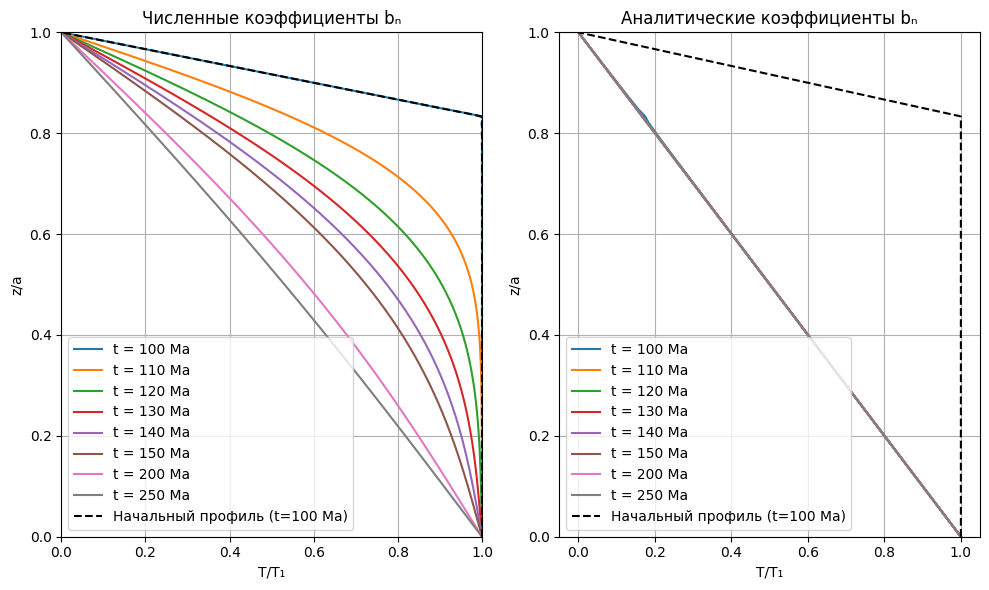

In [79]:
# Основные вычисления
n_max = 100
# G_prime = calculate_G_prime(a, beta, kappa, At_Myr)
# print(f"Безразмерный параметр растяжения G' = {G_prime:.2f}")

# Вычисление коэффициентов
b_n_num = compute_bn_numerical(n_max, z_physical, a, beta, T1)

b_n_anal = compute_bn_analytical(n_max, beta)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

# Численное решение
for t in times_Myr:
    T = temperature_cooling_phase(z_physical, t, At_Myr, a, kappa, b_n_num, n_max, T1)
    ax1.plot(T/T1, z_physical/a, label=f't = {t} Ma')
    # ax1.plot(T, z_physical, label=f't = {t} Ma')

T_init = initial_temp_profile(z_physical, a, beta, T1)
# ax1.plot(T_init/T1, z_physical/a, 'k--', label=f'Начальный профиль (t={At_Myr} Ma)')
ax1.plot(T_init/T1, z_physical/a, 'k--', label=f'Начальный профиль (t={At_Myr} Ma)')
ax1.set(xlabel='T/T₁', ylabel='z/a', title='Численные коэффициенты bₙ')
ax1.legend()
ax1.grid(True)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# Аналитическое решение
for t in times_Myr:
    T = temperature_cooling_phase(z_physical, t, At_Myr, a, kappa, b_n_anal, n_max, T1)
    ax2.plot(T/T1, z_physical/a, label=f't = {t} Ma')

ax2.plot(T_init/T1, z_physical/a, 'k--', label=f'Начальный профиль (t={At_Myr} Ma)')
ax2.set(xlabel='T/T₁', ylabel='z/a', title='Аналитические коэффициенты bₙ')
ax2.legend()
ax2.grid(True)
# ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

# Проверка начального профиля
print("\nПроверка начального профиля:")
print(f"beta = {beta}")
print(f"a*(1-1/beta) = {a*(1-1/beta)} m")
print(f"T на поверхности (z=0) = {initial_temp_profile(0, a, beta, T1):.1f} °C")
print(f"T на глубине a (z={a}) = {initial_temp_profile(a, a, beta, T1):.1f} °C")

# Проверка стационарного решения
print("\nПроверка стационарного решения:")
print(f"T_ss на поверхности (z=0) = {T1*(1-0/a):.1f} °C")
print(f"T_ss на глубине a (z={a}) = {T1*(1-a/a):.1f} °C")

plt.tight_layout()
plt.show()

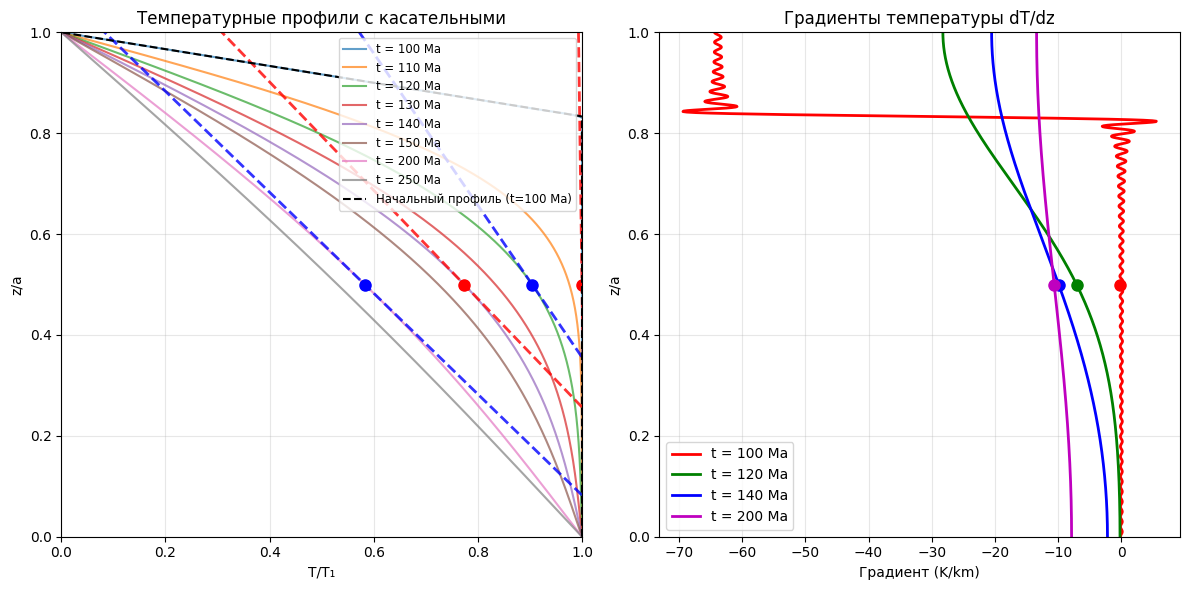


Анализ теплового потока:
Время t = 100 Ma:
  Градиент у поверхности: -0.14 K/km
  Тепловой поток: 0.00 mW/m²


TypeError: unsupported operand type(s) for /: 'list' and 'float'

In [ ]:
# Основные вычисления
n_max = 100

# Вычисление коэффициентов
b_n_num = compute_bn_numerical(n_max, z_physical, a, beta, T1)
b_n_anal = compute_bn_analytical(n_max, beta)

# Создаем фигуру с двумя графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Список времен для построения касательных
# Выберем несколько характерных времен из times_Myr
selected_times = times_Myr[::len(times_Myr)//4]  # Берем 4 равномерно распределенных времени
if len(selected_times) > 4:
    selected_times = selected_times[:4]

# Цвета для касательных
tangent_colors = ['r', 'g', 'b', 'm']

# Функция для вычисления производной температуры по глубине
def compute_temperature_gradient(z, t, At_Myr, a, kappa, b_n, n_max, T1):
    """
    Вычисляет градиент температуры dT/dz
    Используем аналитическое выражение для производной
    """
    dz = z[1] - z[0] if len(z) > 1 else 0.001  # шаг для численного дифференцирования
    T_values = temperature_cooling_phase(z, t, At_Myr, a, kappa, b_n, n_max, T1)
    
    # Численное дифференцирование
    dT_dz = np.gradient(T_values, dz)
    
    return dT_dz, T_values

# График 1: Температурные профили и касательные
for i, t in enumerate(times_Myr):
    T = temperature_cooling_phase(z_physical, t, At_Myr, a, kappa, b_n_num, n_max, T1)
    line = ax1.plot(T/T1, z_physical/a, label=f't = {t} Ma', alpha=0.7)
    
    # Если это выбранное время, строим касательную
    if t in selected_times:
        # Выбираем точку для построения касательной (например, z = a/2)
        z_tangent_point = a / 2
        idx = np.argmin(np.abs(z_physical - z_tangent_point))
        
        # Вычисляем градиент
        dT_dz, T_vals = compute_temperature_gradient(z_physical, t, At_Myr, a, kappa, b_n_num, n_max, T1)
        
        # Уравнение касательной: T(z) = T(z0) + dT/dz|z0 * (z - z0)
        z0 = z_physical[idx]
        T0 = T_vals[idx]
        grad0 = dT_dz[idx]
        
        # Создаем точки для касательной
        z_tangent = np.array([z0 - a*0.6, z0, z0 + a*0.6])  # ±10% от a
        T_tangent = T0 + grad0 * (z_tangent - z0)
        
        # Нормализуем для графика
        color_idx = i % len(tangent_colors)
        ax1.plot(T_tangent/T1, z_tangent/a, '--', 
                color=tangent_colors[color_idx], 
                linewidth=2, alpha=0.8)
        
        # Добавляем точку касания
        ax1.plot(T0/T1, z0/a, 'o', 
                color=tangent_colors[color_idx],
                markersize=8)

# Начальный профиль
T_init = initial_temp_profile(z_physical, a, beta, T1)
ax1.plot(T_init/T1, z_physical/a, 'k--', label=f'Начальный профиль (t={At_Myr} Ma)')

# Настройки графика 1
ax1.set(xlabel='T/T₁', ylabel='z/a', title='Температурные профили с касательными')
ax1.legend(loc='lower left', fontsize='small')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# График 2: Градиенты температур
ax2.set_title('Градиенты температуры dT/dz')
ax2.set_xlabel('Градиент (K/km)')
ax2.set_ylabel('z/a')
ax2.grid(True, alpha=0.3)

for i, t in enumerate(selected_times):
    # Вычисляем градиент
    dT_dz, T_vals = compute_temperature_gradient(z_physical, t, At_Myr, a, kappa, b_n_num, n_max, T1)
    
    # Конвертируем градиент в K/km (предполагая, что z в метрах)
    # Если z в км, уберите умножение на 1000
    gradient_K_per_km = dT_dz * 1000  # K/m to K/km
    
    ax2.plot(gradient_K_per_km, z_physical/a, 
             color=tangent_colors[i], 
             label=f't = {t} Ma', 
             linewidth=2)
    
    # Отмечаем точку, где строилась касательная на первом графике
    z_tangent_point = a / 2
    idx = np.argmin(np.abs(z_physical - z_tangent_point))
    ax2.plot(gradient_K_per_km[idx], z_physical[idx]/a, 'o', 
             color=tangent_colors[i], markersize=8)

ax2.legend()
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Дополнительный анализ: тепловой поток
print("\nАнализ теплового потока:")
print("="*40)

for i, t in enumerate(selected_times):
    # Вычисляем градиент у поверхности (z=0)
    dT_dz, _ = compute_temperature_gradient(z_physical, t, At_Myr, a, kappa, b_n_num, n_max, T1)
    
    # Тепловой поток по закону Фурье: q = -k * dT/dz
    # где k - теплопроводность (обычно 2-3 W/(m·K) для литосферы)
    k_conductivity = 2.5  # W/(m·K) - типичное значение для литосферы
    surface_gradient = dT_dz[0]  # градиент у поверхности
    heat_flow = -k_conductivity * surface_gradient  # W/m²
    
    print(f"Время t = {t} Ma:")
    print(f"  Градиент у поверхности: {surface_gradient*1000:.2f} K/km")
    print(f"  Тепловой поток: {heat_flow:.2f} mW/m²")
    print(f"  Температура у поверхности: {temperature_cooling_phase([0], t, At_Myr, a, kappa, b_n_num, n_max, T1)[0]:.1f} K")
    print("-"*40)

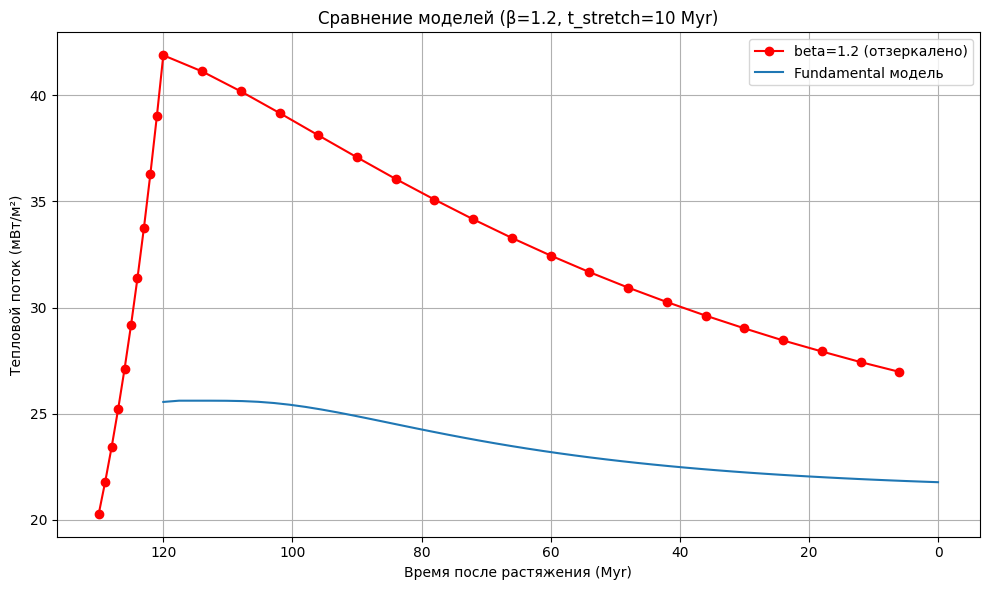

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special

ts_My = 120        # млн лет
t_max_My = 130
beta = 1.2
time_points_m1 = np.array([6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84, 90, 96, 102, 
                        108, 114, 120, 121, 122, 123, 124, 125, 126,127, 128, 129, 130])
heat_flow_m1 = np.array([26.97, 27.43, 27.93, 28.45, 29.02, 29.62, 30.26, 30.94, 31.67, 32.45, 33.28, 34.16, 
             35.09, 36.06, 37.08, 38.12, 39.17, 40.19, 41.13, 41.89, 39.01, 36.3, 33.76, 31.39, 
             29.17, 27.11, 25.2, 23.43, 21.79, 20.28])

# Исходные значения
k_m2_s = 1.234e-6      # м²/с
lam_w_mk = 2           # Вт/(м·K)

# Перевод термодиффузии: м²/с → см²/с
k_cm2_s = k_m2_s * 1e4

# Перевод теплопроводности: Вт/(м·K) → кал/(см·с·°C)
lam_cal_cmC_s = lam_w_mk * 0.239005736 / 100

def heat_flow_fundament_calculation(beta, t, t_stretching, Q_const=63e-3, a=1.25e7, 
                                  k=k_cm2_s, lam=lam_cal_cmC_s, T1=1333, n_terms=100):
    """Расчёт теплового потока для моделей растяжения литосферы"""
    if beta <= 0:
        raise ValueError("Stretching factor beta must be positive")
    if np.any(t < 0):
        raise ValueError("Time t must be non-negative")
    if t_stretching < 0:
        raise ValueError("Stretching time t_stretching must be non-negative")

    MYR_TO_S = 1e6 * 3.154e7
    tau_s = (a**2) / (np.pi**2 * k)
    tau_myr = tau_s / MYR_TO_S

    if t_stretching <= 30:
        n = np.arange(1, n_terms + 1)
        exponent = -np.outer(n**2, (t - t_stretching)) / tau_myr
        sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
        Cn = (beta * sin_term[:, np.newaxis]) * np.exp(exponent)
        F_sum = np.sum(Cn, axis=0)
    else:
        n = 1
        exponent = -n**2 * (t - t_stretching) / tau_myr
        sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
        F_sum = (beta * sin_term) * np.exp(exponent)

    heat_flux_cal = (lam * T1 / a) * (1 + 2 * F_sum)
    return heat_flux_cal * 41868  # мВт/м²

def heat_flow_jarvis_mckenzie(beta, t, t_stretching, a=1.25e7, kappa=k_cm2_s, 
                             lam=lam_cal_cmC_s, T1=1333):
    """Модель Jarvis & McKenzie с исправлением размерностей"""
    MYR_TO_S = 1e6 * 3.154e7
    G = np.log(beta) / (t_stretching * MYR_TO_S)
    G_prime = (a**2 * G) / kappa
    
    steady_term = np.sqrt(2 * G_prime / np.pi) / scipy.special.erf(np.sqrt(G_prime / 2))
    
    tau = a**2 / (np.pi**2 * kappa)
    tau_myr = tau / MYR_TO_S
    
    # Исправление: учитываем размерности массивов
    n = np.arange(1, 101)
    t_rel = np.atleast_1d(t - t_stretching)
    exponent = -np.outer(n**2, t_rel) / tau_myr
    
    fourier_terms = (beta / (n * np.pi)) * np.sin(n * np.pi / beta)
    fourier_term = np.sum(fourier_terms[:, np.newaxis] * np.exp(exponent), axis=0)
    
    heat_flow_cal = (lam * T1 / a) * (steady_term + fourier_term)
    return heat_flow_cal * 41868  # мВт/м²

# Параметры для расчета
beta = 1.2
t_myr = np.linspace(10, 130, 50)
t_stretching = 10

# Расчет тепловых потоков
heat_flow_1 = heat_flow_fundament_calculation(beta=beta, t=t_myr, t_stretching=t_stretching) * 1e3
heat_flow_2 = heat_flow_jarvis_mckenzie(beta=beta, t=t_myr, t_stretching=t_stretching) * 1e3


# Визуализация
plt.figure(figsize=(10, 6))

plt.plot(time_points_m1, heat_flow_m1, marker='o', color='red', label='beta=1.2 (отзеркалено)')  # Отзеркалено по X
plt.gca().invert_xaxis()  # Инвертирует ось X

plt.plot((t_myr - t_stretching)[::-1], heat_flow_1, label='Fundamental модель')
# plt.plot((t_myr - t_stretching)[::-1], heat_flow_2, '--', label='Jarvis & McKenzie')

plt.xlabel('Время после растяжения (Myr)')
plt.ylabel('Тепловой поток (мВт/м²)')
plt.title(f'Сравнение моделей (β={beta}, t_stretch={t_stretching} Myr)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

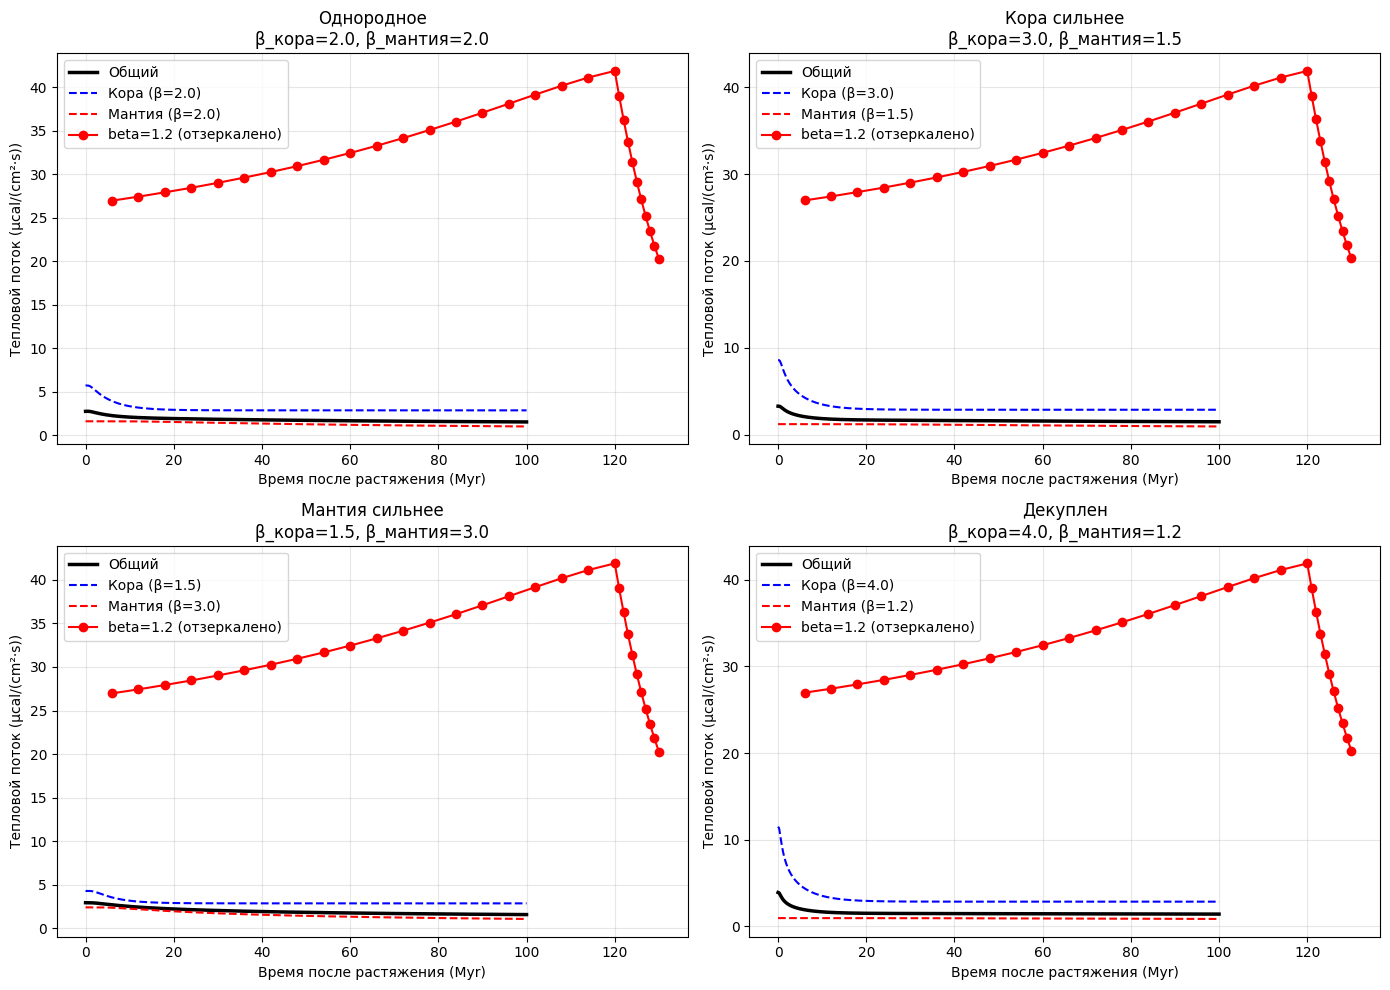

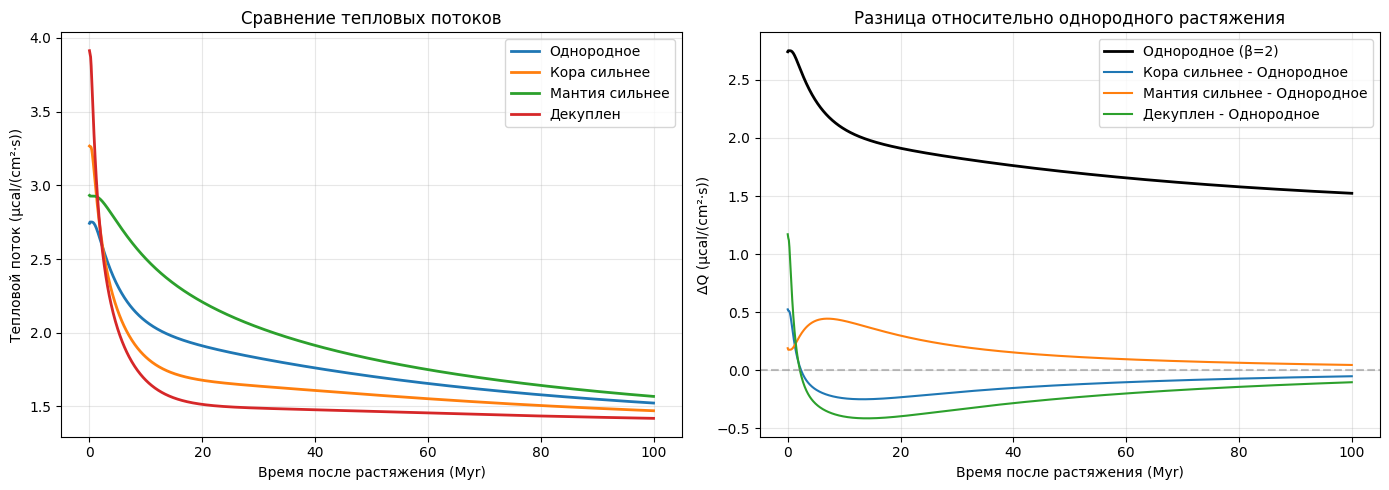

Анализ максимальных тепловых потоков:
--------------------------------------------------
Однородное           β_кор=2.0 β_ман=2.0
  Максимальный поток: 2.75 µcal/(cm²·s)
  Установившийся: 1.52 µcal/(cm²·s)
  Отношение max/steady: 1.81

Кора сильнее         β_кор=3.0 β_ман=1.5
  Максимальный поток: 3.27 µcal/(cm²·s)
  Установившийся: 1.47 µcal/(cm²·s)
  Отношение max/steady: 2.22

Мантия сильнее       β_кор=1.5 β_ман=3.0
  Максимальный поток: 2.93 µcal/(cm²·s)
  Установившийся: 1.57 µcal/(cm²·s)
  Отношение max/steady: 1.87

Декуплен             β_кор=4.0 β_ман=1.2
  Максимальный поток: 3.91 µcal/(cm²·s)
  Установившийся: 1.42 µcal/(cm²·s)
  Отношение max/steady: 2.76



In [74]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Union

def heat_flow_two_layer_complete(
    beta_crust: float,
    beta_mantle: float,
    t: Union[float, np.ndarray],
    a_total: float = 125e5,      # cm (125 км)
    a_crust: float = 35e5,       # cm (35 км)
    T1: float = 1333,            # °C
    kappa: float = 0.00804,      # cm²/s
    lam: float = 0.0075,         # cal/(°C·cm·s)
    n_terms: int = 100
) -> tuple:
    """
    Полная двухслойная модель растяжения.
    
    Возвращает:
    - Q_total_mucal: общий тепловой поток (µcal/(cm²·s))
    - Q_crust_mucal: вклад коры
    - Q_mantle_mucal: вклад мантии
    - Q_total_mw: общий тепловой поток (mW/m²)
    """
    MYR_TO_S = 1e6 * 3.154e7
    
    # Проверка корректности β
    if beta_crust < 1 or beta_mantle < 1:
        raise ValueError("Beta values must be ≥ 1")
    
    # Функция расчета для одного слоя
    def layer_heat_flow(beta, thickness, time_array):
        tau = (thickness**2) / (np.pi**2 * kappa) / MYR_TO_S
        
        n = np.arange(1, n_terms + 1)
        exponent = -np.outer(n**2, time_array) / tau
        sin_term = np.sin(n * np.pi / beta) / (n * np.pi)
        Cn = (beta * sin_term[:, np.newaxis]) * np.exp(exponent)
        F = np.sum(Cn, axis=0)
        
        return (lam * T1 / thickness) * (1 + 2 * F)
    
    # Расчет для каждого слоя
    Q_crust = layer_heat_flow(beta_crust, a_crust, t)
    Q_mantle = layer_heat_flow(beta_mantle, a_total, t)
    
    # Комбинирование потоков (упрощенное - можно улучшить)
    # Веса пропорциональны толщинам слоев
    weight_crust = a_crust / a_total
    weight_mantle = 1 - weight_crust
    
    Q_total = weight_crust * Q_crust + weight_mantle * Q_mantle
    
    # Конвертация единиц
    Q_crust_mucal = Q_crust * 1e6
    Q_mantle_mucal = Q_mantle * 1e6
    Q_total_mucal = Q_total * 1e6
    Q_total_mw = Q_total * 41868
    
    return Q_total_mucal, Q_crust_mucal, Q_mantle_mucal, Q_total_mw

# Параметры для анализа
t_myr = np.linspace(0, 100, 1000)

# Сценарии растяжения
scenarios = [
    {"name": "Однородное", "beta_crust": 2.0, "beta_mantle": 2.0},
    {"name": "Кора сильнее", "beta_crust": 3.0, "beta_mantle": 1.5},
    {"name": "Мантия сильнее", "beta_crust": 1.5, "beta_mantle": 3.0},
    {"name": "Декуплен", "beta_crust": 4.0, "beta_mantle": 1.2},
]

# Создание графиков
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, scenario in enumerate(scenarios):
    beta_crust = scenario["beta_crust"]
    beta_mantle = scenario["beta_mantle"]
    
    # Расчет
    Q_total, Q_crust, Q_mantle, Q_total_mw = heat_flow_two_layer_complete(
        beta_crust, beta_mantle, t_myr
    )
    
    # График 1: Тепловой поток (µcal/(cm²·s))
    ax = axes[idx]
    ax.plot(t_myr, Q_total, 'k-', linewidth=2.5, label='Общий')
    ax.plot(t_myr, Q_crust, 'b--', linewidth=1.5, label=f'Кора (β={beta_crust})')
    ax.plot(t_myr, Q_mantle, 'r--', linewidth=1.5, label=f'Мантия (β={beta_mantle})')
    ax.plot(time_points_m1, heat_flow_m1, marker='o', color='red', label='beta=1.2 (отзеркалено)')  # Отзеркалено по X
    plt.gca().invert_xaxis()  # Инвертирует ось X
    
    ax.set_title(f"{scenario['name']}\nβ_кора={beta_crust}, β_мантия={beta_mantle}")
    ax.set_xlabel("Время после растяжения (Myr)")
    ax.set_ylabel("Тепловой поток (µcal/(cm²·s))")
    ax.grid(True, alpha=0.3)
    ax.legend()
    # ax.set_ylim(0, 4)

plt.tight_layout()
plt.show()

# Дополнительный график: сравнение сценариев
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for scenario in scenarios:
    beta_crust = scenario["beta_crust"]
    beta_mantle = scenario["beta_mantle"]
    
    Q_total, _, _, _ = heat_flow_two_layer_complete(beta_crust, beta_mantle, t_myr)
    
    ax1.plot(t_myr, Q_total, linewidth=2, label=scenario["name"])
    
    # Интересно посмотреть на мгновенные значения
    if scenario["name"] == "Однородное":
        ax2.plot(t_myr, Q_total, 'k-', linewidth=2, label='Однородное (β=2)')
    else:
        # Разница относительно однородного случая
        Q_uniform, _, _, _ = heat_flow_two_layer_complete(2.0, 2.0, t_myr)
        diff = Q_total - Q_uniform
        ax2.plot(t_myr, diff, linewidth=1.5, label=f"{scenario['name']} - Однородное")

ax1.set_title("Сравнение тепловых потоков")
ax1.set_xlabel("Время после растяжения (Myr)")
ax1.set_ylabel("Тепловой поток (µcal/(cm²·s))")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.set_title("Разница относительно однородного растяжения")
ax2.set_xlabel("Время после растяжения (Myr)")
ax2.set_ylabel("ΔQ (µcal/(cm²·s))")
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Анализ влияния параметров
print("Анализ максимальных тепловых потоков:")
print("-" * 50)
for scenario in scenarios:
    beta_crust = scenario["beta_crust"]
    beta_mantle = scenario["beta_mantle"]
    
    Q_total, _, _, _ = heat_flow_two_layer_complete(beta_crust, beta_mantle, t_myr)
    
    Q_max = np.max(Q_total)
    Q_steady = Q_total[-1]  # Значение при t=100 Myr
    
    print(f"{scenario['name']:20} β_кор={beta_crust:3.1f} β_ман={beta_mantle:3.1f}")
    print(f"  Максимальный поток: {Q_max:.2f} µcal/(cm²·s)")
    print(f"  Установившийся: {Q_steady:.2f} µcal/(cm²·s)")
    print(f"  Отношение max/steady: {Q_max/Q_steady:.2f}")
    print()

## Рисунок - Эволюция температуры на фиксированной глубине (z/a = const) после растяжения литосферы

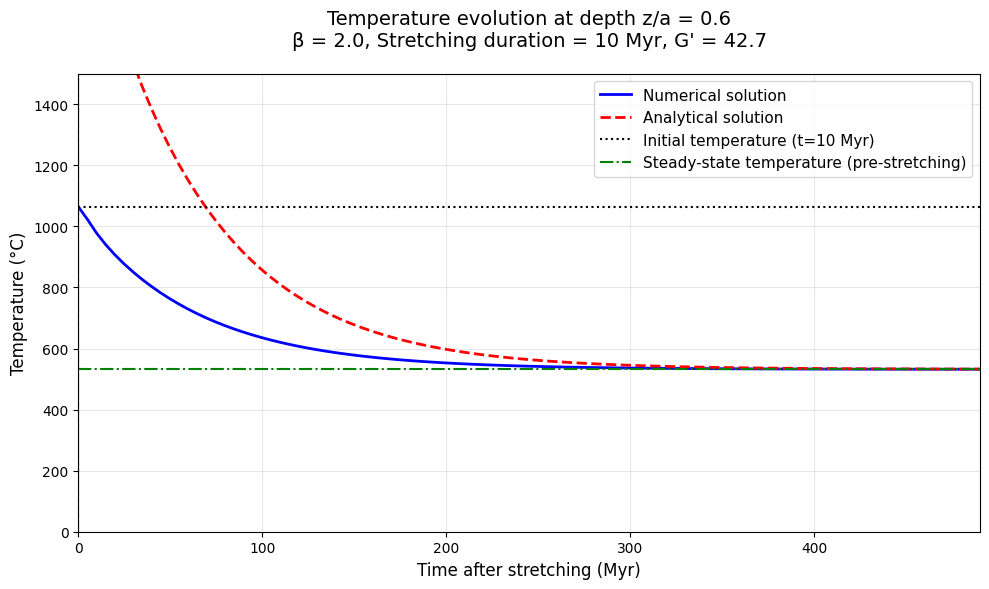

In [4]:
# Calculate temperature evolution at fixed depth z/a = 0.6
z_fixed_ratio = 0.6
z_fixed = z_fixed_ratio * a
time_array = np.linspace(At_Myr, 500, 100)  # Time points from stretching end to 500 Myr

# Calculate coefficients
b_n_num = compute_bn_numerical(n_max, z_physical, a, beta, T1)
b_n_analytical = compute_bn_analytical(n_max, beta)

# Compute temperature evolution
T_num = np.array([temperature_cooling_phase(np.array([z_fixed]), t, At_Myr, a, kappa, b_n_num, n_max, T1)[0] 
                 for t in time_array])
T_analytical = np.array([temperature_cooling_phase(np.array([z_fixed]), t, At_Myr, a, kappa, b_n_analytical, n_max, T1)[0] 
                        for t in time_array])

# Reference temperatures
T_initial = initial_temp_profile(np.array([z_fixed]), a, beta, T1)[0]
T_steady_state = T1 * (1 - z_fixed_ratio)

# Create plot
plt.figure(figsize=(10, 6))

# Plot temperature evolution
plt.plot(time_array - At_Myr, T_num, 'b-', linewidth=2, label='Numerical solution')
plt.plot(time_array - At_Myr, T_analytical, 'r--', linewidth=2, label='Analytical solution')

# Reference lines
plt.axhline(T_initial, color='k', linestyle=':', linewidth=1.5, 
            label=f'Initial temperature (t={At_Myr} Myr)')
plt.axhline(T_steady_state, color='g', linestyle='-.', linewidth=1.5, 
            label='Steady-state temperature (pre-stretching)')

# Formatting
plt.xlabel('Time after stretching (Myr)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title(f'Temperature evolution at depth z/a = {z_fixed_ratio}\n'
         f'β = {beta}, Stretching duration = {At_Myr} Myr, G\' = {G_prime:.1f}', 
         fontsize=14, pad=20)

plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 500 - At_Myr)
plt.ylim(0, 1500)  # Adjusted for normalized temperature

# Add vertical line for stretching end
plt.axvline(0, color='gray', linestyle='--', alpha=0.7, linewidth=1)

plt.tight_layout()
plt.show()

# Температура в фазе растяжения (рифтинга)

## Модель растяжения литосферы Маккензи (1980) - Основные уравнения

### 1. Стационарная температура (Уравнение 14)
Профиль температуры в установившемся режиме при растяжении:
$$
T_0(z) = -T_1 \frac{\text{erf}\left((z/a - 1)\sqrt{G'/2}\right)}{\text{erf}\left(\sqrt{G'/2}\right)}
$$
где:
- $ z $ = глубина (размерная)
- $ z' = z/a $ = безразмерная глубина
- $ G' = a^2 G / \kappa $ = безразмерная скорость растяжения
- $ T_1 $ = температура астеносферы

---

### 2. Нестационарная температура (Уравнение 13 / Приложение A-16)
Полное временное решение:
$$
T(z, t) = T_0(z) + T_1 \sum_{n=1}^{\infty} ( a_n ) \theta_n(z) e^{-K_n \kappa t / a^2}
$$
где:
- $( a_n )$ = коэффициенты проекции
- $ \theta_n(z) $ = собственные функции
- $ K_n $ = собственные значения
- $ t $ = время с начала растяжения

---

### 3. Задача на собственные значения (Приложение A-3)
Уравнение для собственных функций $ \theta_n $:
$$
\frac{d^2\theta}{dz'^2} + G'(z' - 1)\frac{d\theta}{dz'} + K\theta = 0
$$
Граничные условия: $ \theta(0) = \theta(1) = 0 $.

---

### 4. Расчет коэффициентов (Приложение A-18)
Коэффициенты $( a_n )$:
$$
( a_n ) = \frac{\int_0^1 \left[(1 - z') + \frac{\text{erf}[(z' - 1)\sqrt{G'/2}]}{\text{erf}\sqrt{G'/2}}\right] \theta_n e^{(z'-1)^2 G'/2} dz'}{\int_0^1 \theta_n^2 e^{(z'-1)^2 G'/2} dz'}
$$

---

### 5. Безразмерное масштабирование времени
Преобразование из миллионов лет в безразмерное время:
$$
t' = \frac{\kappa t}{a^2} \approx \frac{t_{\text{Млн лет}}}{616} \quad \text{(для } a = 125 \text{ км, } \kappa = 8.04 \times 10^{-7} \text{ м}^2/\text{с)}
$$

---

### 6. Начальное условие
При $ t = 0 $:
$$
T(z, 0) = T_1 (1 - z/a)
$$

---

### 7. Предельные случаи собственных значений
- **Диффузионный предел** ($ G' \to 0 $):
  $$ K_n \approx n^2 \pi^2 $$
- **Адвективный предел** ($ G' \gg 1 $):
  $$ K_n \approx 2n G' $$

---

### 8. Уравнения субсиденции (из статьи)
#### Общая субсиденция (Уравнение 8):
$$
S_{\text{total}} = \frac{(\rho_0 - \rho_c)t_c}{\rho_0(1 - \alpha T_1) - \rho_w} \left[ \left(1 - \frac{1}{\beta}\right) - \frac{\alpha T_1 t_c}{2a}\left(1 - \frac{1}{\beta^2}\right) \right]
$$

#### Пост-экстензионная субсиденция (Уравнение 27):
$$
S_G = \frac{-a\alpha T_1}{[\rho_0(1 - \alpha T_1) - \rho_w + Bt_c/a]\pi} \sum_{n=1}^{\infty} \frac{b_n}{n} \left[ \rho_0(1 - \cos n\pi (1 - t_c/a)) + \rho_c (\cos n\pi (1 - t_c/a) - (-1)^n) \right]
$$

---

In [5]:
import numpy as np
from scipy.integrate import solve_bvp, trapezoid
from scipy.special import erf
import matplotlib.pyplot as plt

In [6]:
# Physical parameters from Table 1 (McKenzie 1978)
a_km = 125               # Lithosphere thickness (km)
a = a_km * 1e3           # Convert to meters
kappa = 8.04e-7          # Thermal diffusivity (m²/s)
T1 = 1330                # Asthenospheric temperature (°C)
alpha = 3.28e-5          # Thermal expansion coefficient (°C⁻¹)
rho_0 = 3.33e3           # Lithosphere density at 0°C (kg/m³)
rho_c = 2.8e3            # Crust density at 0°C (kg/m³)
rho_w = 1.03e3           # Water density (kg/m³)
t_c_km = 35              # Initial crustal thickness (km)
t_c = t_c_km * 1e3       # Convert to meters

### Численное решение задачи на собственные значения (Приложение A-3)

**Ключевые элементы:**

1. **Уравнение задачи:**
   $$
   \frac{d^2\theta}{dz^2} + G'(z-1)\frac{d\theta}{dz} + K\theta = 0
   $$

2. **Численный метод:**
   - Используется метод `solve_bvp` из SciPy
   - Расчет собственных значений $K_n$
   - Расчет собственных функций $\theta_n(z)$

3. **Начальные условия:**
   - Определение коэффициентов $a_n$ для температурных мод
   - Численная реализация уравнения (A-18) из статьи

4. **Связь с моделью:**
   - Полученные $K_n$ и $\theta_n(z)$ используются для построения температурного профиля во время фазы растяжения
   - Коэффициенты $a_n$ определяют начальное условие для фазы охлаждения

**Примечание:** Для $G' \ll 1$: $K_n \approx n^2\pi^2$, $\theta_n \approx \sin(n\pi z)$  
Для $G' \gg 1$: $K_n \approx 2nG'$, $\theta_n$ локализованы у верхней границы

In [7]:
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

def solve_eigenproblem(G_prime, n_eigenvalues=2, prev_eigenfunctions=None, prev_eigenvalues=None):
    """
    Решает задачу на собственные значения для уравнения (A-3) из статьи McKenzie (1980):
    theta'' + G'(z-1)theta' + K*theta = 0
    с граничными условиями theta(0)=0, theta(1)=0, theta'(0)=1
    
    Параметры:
        G_prime - безразмерный параметр растяжения (a²G/κ)
        n_eigenvalues - число вычисляемых собственных значений
    """
    def initial_eigenvalue_guess(n, G_prime):
        """Начальное приближение для K_n согласно аналитическим оценкам из статьи"""
        if G_prime <= 1.0:
            return (n * np.pi) ** 2  # Диффузионный предел (уравнение перед A-4)
        elif G_prime > 1 and G_prime < 10:
            return 2 * n * G_prime + (n * np.pi) ** 2 * 0.2  # Промежуточный режим   
        else:
            return 2 * n * G_prime  # Адвективный предел (для G' >= 10)

    # Уравнение A-3 в канонической форме (раздел Appendix)
    def ode(z, y, p):
        """Система ОДУ 1-го порядка для уравнения (A-3):
        y[0] = theta(z)
        y[1] = theta'(z)
        p[0] = K (собственное значение)
        """
        return [y[1], -G_prime * (z - 1) * y[1] - p[0] * y[0]]

    def bc(ya, yb, p):
        """Граничные условия:
        ya[0] = theta(0) = 0
        yb[0] = theta(1) = 0
        ya[1] = theta'(0) = 1
        """
        return [ya[0], yb[0], ya[1] - 1]

    # Неравномерная сетка (гуще у z=1 для разрешения пограничного слоя при больших G')
    z_coarse = np.linspace(0, 0.95, 500)
    z_fine = np.linspace(0.95, 1.0, 5000)
    z = np.unique(np.concatenate((z_coarse, z_fine)))

    y_guess = np.zeros((2, len(z)))
    eigenvalues = []
    eigenfunctions = []

    delta = 1.0 / np.sqrt(G_prime) if G_prime >= 10 else 1.0  # Толщина пограничного слоя

    for n in range(1, n_eigenvalues + 1):
        K_guess = initial_eigenvalue_guess(n, G_prime)

        # Начальное приближение для метода стрельбы
        if prev_eigenfunctions is not None:
            try:  # Используем предыдущее решение как начальное приближение
                prev_theta = prev_eigenfunctions[n - 1](z)
                y_guess[0] = prev_theta[0]
                y_guess[1] = prev_theta[1]
                scaling = 1.0 / y_guess[1][0]  # Нормировка theta'(0)=1
                y_guess[0] *= scaling
                y_guess[1] *= scaling
                K_guess = prev_eigenvalues[n - 1]
            except:
                # Аппроксимация с пограничным слоем (для больших G')
                y_guess[0] = (z * (1 - z)) * np.exp(-(1 - z) / delta) * np.sin(n * np.pi * z)
                y_guess[1] = np.gradient(y_guess[0], z)
                scaling = 1.0 / y_guess[1][0]
                y_guess[0] *= scaling
                y_guess[1] *= scaling
        else:
            if G_prime < 10.0:
                y_guess[0] = np.sin(n * np.pi * z)  # Диффузионное приближение
                y_guess[1] = n * np.pi * np.cos(n * np.pi * z)
            else:
                y_guess[0] = (z * (1 - z)) * np.exp(-(1 - z) / delta) * np.sin(n * np.pi * z)
                y_guess[1] = np.gradient(y_guess[0], z)
                scaling = 1.0 / y_guess[1][0]
                y_guess[0] *= scaling
                y_guess[1] *= scaling

        sol = solve_bvp(ode, bc, z, y_guess, p=[K_guess], tol=1e-5, max_nodes=1000000)

        if not sol.success:
            raise RuntimeError(f"Сходимость не достигнута для моды {n} при G'={G_prime}: {sol.message}")

        eigenvalues.append(sol.p[0])
        eigenfunctions.append(sol.sol)
        y_guess = sol.sol(z)

    return eigenvalues, eigenfunctions

# Progressive solve of eigenproblems at intermediate G' values for better convergence
G_values = [10, 15, 20, 25, 30, 35, 40, 50, 70, 85, 90, 95, 98, 100]

prev_eigfuncs = None
prev_eigvals = None
eigenfunctions_dict = {}

for G in G_values:
    print(f"Solving eigenproblem for G' = {G} ...")
    eigvals, eigfuncs = solve_eigenproblem(G, n_eigenvalues=2,
                                           prev_eigenfunctions=prev_eigfuncs,
                                           prev_eigenvalues=prev_eigvals)
    eigenfunctions_dict[G] = (eigvals, eigfuncs)
    prev_eigfuncs = eigfuncs
    prev_eigvals = eigvals

print("Eigenvalues for G'=10:", eigenfunctions_dict[10][0])
print("Eigenvalues for G'=100:", eigenfunctions_dict[100][0])

Solving eigenproblem for G' = 10 ...
Solving eigenproblem for G' = 15 ...
Solving eigenproblem for G' = 20 ...
Solving eigenproblem for G' = 25 ...
Solving eigenproblem for G' = 30 ...
Solving eigenproblem for G' = 35 ...
Solving eigenproblem for G' = 40 ...
Solving eigenproblem for G' = 50 ...
Solving eigenproblem for G' = 70 ...
Solving eigenproblem for G' = 85 ...
Solving eigenproblem for G' = 90 ...
Solving eigenproblem for G' = 95 ...
Solving eigenproblem for G' = 98 ...
Solving eigenproblem for G' = 100 ...
Eigenvalues for G'=10: [np.float64(21.28561822162131), np.float64(52.64434617218265)]
Eigenvalues for G'=100: [np.float64(999.9999978387824), np.float64(799.9999986349417)]


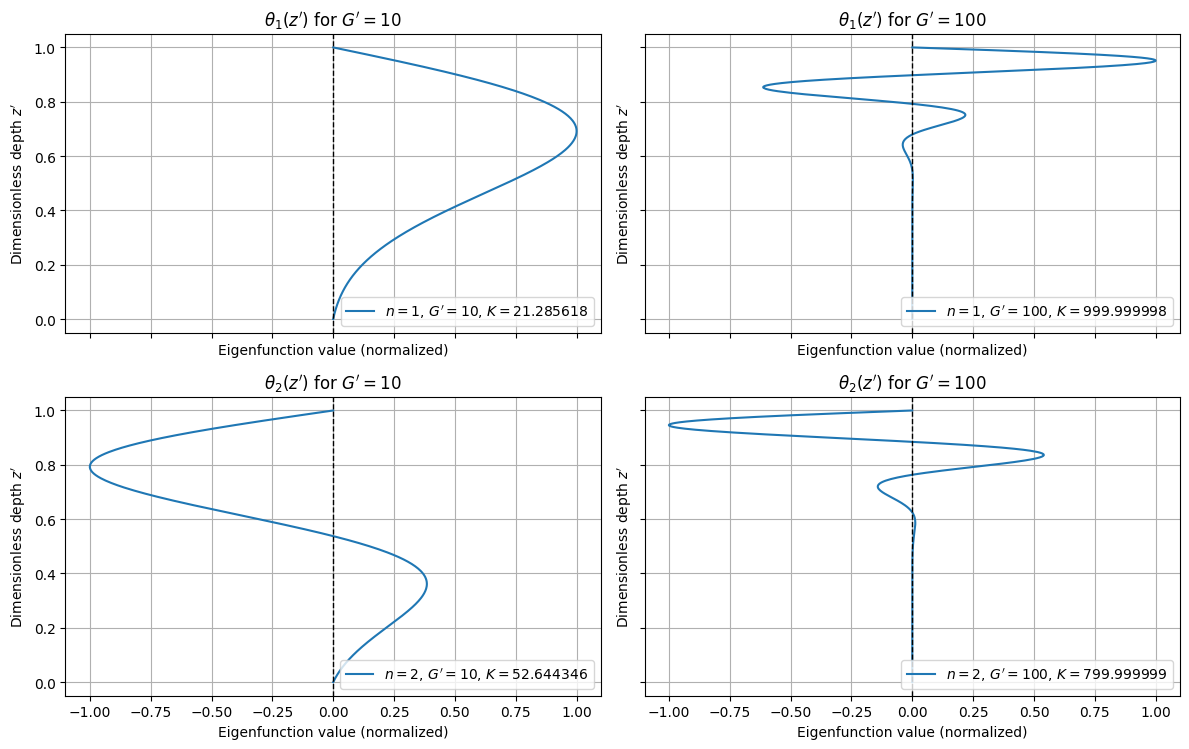

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

G_vals = [10, 100]
z_plot_lower = np.linspace(0, 0.85, 300)
z_plot_upper = np.linspace(0.85, 1, 700)
z_plot = np.unique(np.concatenate((z_plot_lower, z_plot_upper)))

weight = 1  # If you want weighting, replace with: np.exp((z_plot - 1) ** 2 * G / 2)

# Upper row, n = 1
for col, G in enumerate(G_vals):
    eigvals, eigfuncs = eigenfunctions_dict[G]
    theta_vals = eigfuncs[0](z_plot)[0]
    weighted_theta = theta_vals * weight
    weighted_theta /= np.max(np.abs(weighted_theta))
    axs[0, col].plot(weighted_theta, z_plot, label=f'$n=1$, $G\'={G}$, $K={eigvals[0]:.6f}$')
    axs[0, col].set_title(f"$\\theta_{{1}}(z')$ for $G'={G}$")
    axs[0, col].set_xlabel("Eigenfunction value (normalized)")
    axs[0, col].set_ylabel("Dimensionless depth $z'$")
    axs[0, col].legend(loc='lower right')
    axs[0, col].grid(True)
    axs[0, col].invert_yaxis()
    axs[0, col].axvline(0, color='k', linestyle='--', linewidth=1)  # Vertical line at x=0

# Lower row, n = 2
for col, G in enumerate(G_vals):
    eigvals, eigfuncs = eigenfunctions_dict[G]
    theta_vals = eigfuncs[1](z_plot)[0]
    weighted_theta = theta_vals * weight
    weighted_theta /= np.max(np.abs(weighted_theta))
    axs[1, col].plot(weighted_theta, z_plot, label=f'$n=2$, $G\'={G}$, $K={eigvals[1]:.6f}$')
    axs[1, col].set_title(f"$\\theta_{{2}}(z')$ for $G'={G}$")
    axs[1, col].set_xlabel("Eigenfunction value (normalized)")
    axs[1, col].set_ylabel("Dimensionless depth $z'$")
    axs[1, col].legend(loc='lower right')
    axs[1, col].grid(True)
    axs[1, col].invert_yaxis()
    axs[1, col].axvline(0, color='k', linestyle='--', linewidth=1)  # Vertical line at x=0

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


G' = 100:
  K_1 = 2418.07
  K_2 = 2204.71


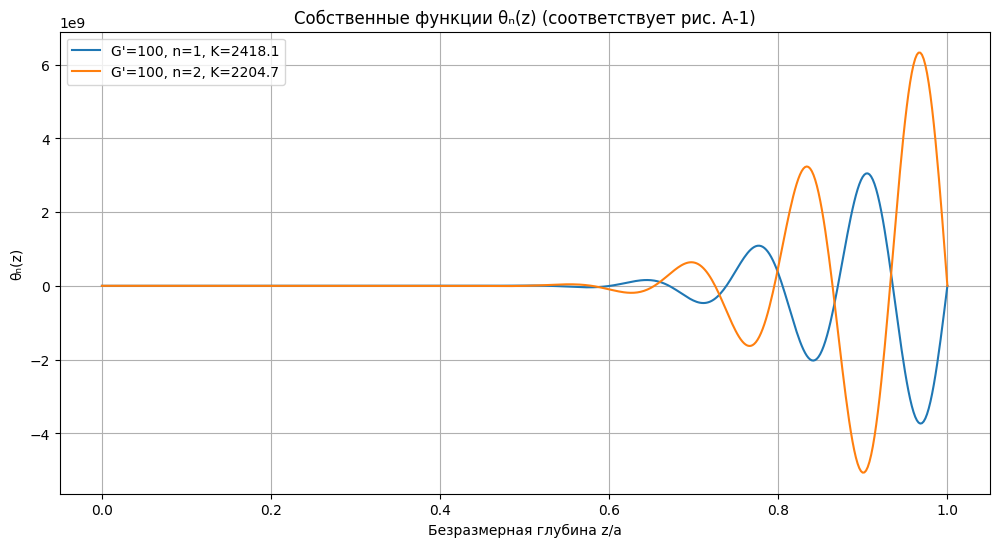

In [9]:
# Параметры расчета (соответствуют рис. A-1)
G_values = [100]  # Значения G' для визуализации
n_modes = 2  # Число мод

# Решение и визуализация
plt.figure(figsize=(12, 6))
for G in G_values:
    eigenvalues, eigenfunctions = solve_eigenproblem(G, n_eigenvalues=n_modes)
    
    print(f"G' = {G}:")
    for i, K in enumerate(eigenvalues):
        print(f"  K_{i+1} = {K:.2f}")
    
    # Построение графиков (аналог рис. A-1)
    z_plot = np.linspace(0, 1, 500)
    for i in range(n_modes):
        theta = eigenfunctions[i](z_plot)[0]
        plt.plot(z_plot, theta, label=f'G\'={G}, n={i+1}, K={eigenvalues[i]:.1f}')

plt.title('Собственные функции θₙ(z) (соответствует рис. A-1)')
plt.xlabel('Безразмерная глубина z/a')
plt.ylabel('θₙ(z)')

plt.legend()
plt.grid(True)
plt.show()

### Расчет коэффициентов $( a_n )$ (Приложение A-18)

**Физическая согласованность:**
- При G'→0 коэффициенты $a_n$ должны стремиться к коэффициентам Фурье для $sin(nπz)$
- При больших G' основные вклады должны приходиться на область $z≈1$


## Проверка коэффициентов $( a_n )$ в диффузионном пределе $( G' \rightarrow 0 )$

Для начального условия:
$$ f(z) = 1 - z - T_0(z)/T_1 \approx 1 - z \quad \text{(при } G' \rightarrow 0 \text{)} $$

### Аналитическое решение:
Разложение в ряд Фурье по синусам:
$$ f(z) = \sum_{n=1}^{\infty} ( a_n ) \sin(n\pi z) $$

Коэффициенты Фурье:
$$ ( a_n ) = 2 \int_0^1 (1 - z) \sin(n\pi z) dz = \begin{cases} 
\frac{4}{n\pi}, & n \text{ нечётное} \\ 
0, & n \text{ чётное} 
\end{cases} $$

### Ожидаемые значения:
| $( n )$ | Аналитическое $( a_n )$ | Приближённое значение |
|---------|-------------------------|-----------------------|
| 1       | $( \frac{4}{\pi} )$     | 1.2732                |
| 2       | 0                       | 0                     |
| 3       | $( \frac{4}{3\pi} )$    | 0.4244                |
| 4       | 0                       | 0                     |
| 5       | $( \frac{4}{5\pi} )$    | 0.2546                |

**Критерии корректности:**

- Для нечётных $( n )$ численные $( a_n )$ должны стремиться к $( \frac{4}{n\pi} )$
- Для чётных $( n )$ коэффициенты должны быть близки к нулю
- Относительная погрешность должна уменьшаться при $( G' \rightarrow 0 )$

In [10]:
import numpy as np
from scipy.integrate import trapezoid
from scipy.special import erf
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

# Constants
seconds_per_Myr = 1e6 * 365.25 * 24 * 3600
a = 125000  # m
kappa = 8.04e-7  # m²/s
T1 = 1333  # °C

def steady_state_temperature(z_prime, G_prime, T1):
    """Steady-state analytic solution - Eq. (14)."""
    numerator = erf((z_prime - 1) * np.sqrt(G_prime / 2))
    denominator = erf(np.sqrt(G_prime / 2))
    return -T1 * numerator / denominator

def solve_eigenproblem(G_prime, n_eigenvalues=5):
    """Solves the eigenvalue problem for given G'"""
    def initial_eigenvalue_guess(n, G_prime):
        if G_prime <= 1.0:
            return (n * np.pi) ** 2
        elif G_prime >= 10.0:
            return 2 * n * G_prime
        else:
            w = (G_prime - 1) / 9  # Normalized weight between 1 and 10
            return (1-w)*(n*np.pi)**2 + w*2*n*G_prime

    def ode(z, y, p):
        return [y[1], -G_prime*(z-1)*y[1] - p[0]*y[0]]

    def bc(ya, yb, p):
        return [ya[0], yb[0], ya[1]-1]  # θ(0)=0, θ(1)=0, θ'(0)=1

    # Adaptive mesh - denser near z=1 for large G'
    if G_prime > 10:
        z_coarse = np.linspace(0, 0.9, 300)
        z_fine = np.linspace(0.9, 1, 700)
        z = np.unique(np.concatenate([z_coarse, z_fine]))
    else:
        z = np.linspace(0, 1, 1000)

    y_guess = np.zeros((2, len(z)))
    eigenvalues = []
    eigenfunctions = []

    for n in range(1, n_eigenvalues+1):
        K_guess = initial_eigenvalue_guess(n, G_prime)
        
        # Improved initial guess
        if G_prime < 1.0:
            y_guess[0] = np.sin(n*np.pi*z)
            y_guess[1] = n*np.pi*np.cos(n*np.pi*z)
        else:
            boundary_layer = np.exp(-G_prime*(1-z))
            y_guess[0] = boundary_layer * np.sin(n*np.pi*z)
            y_guess[1] = np.gradient(y_guess[0], z)
        
        # Normalize initial guess
        y_guess[1] /= y_guess[1][0]

        sol = solve_bvp(ode, bc, z, y_guess, p=[K_guess], tol=1e-6, max_nodes=100000)
        if not sol.success:
            raise RuntimeError(f"Solver failed for mode {n} at G'={G_prime}")

        eigenvalues.append(sol.p[0])
        eigenfunctions.append(sol.sol)
        y_guess = sol.sol(z)  # Use as guess for next mode

    return eigenvalues, eigenfunctions

def compute_coefficients(G_prime, eigenvalues, eigenfunctions, beta):
    """Compute coefficients a_n according to McKenzie (1980)"""
    z = np.linspace(0, 1, 5000)
    weight = np.exp((z-1)**2 * G_prime/2)
    
    # Initial temperature profile (Eq. 20)
    T_initial = np.where(z <= (1-1/beta), 
                        T1, 
                        T1*beta*(1-z))
    
    # Steady state profile (Eq. 14)
    T0 = steady_state_temperature(z, G_prime, T1)
    
    # Deviation from steady state (for Eq. 19)
    deviation = (T_initial - T0)/T1
    
    a_n = []
    for theta in eigenfunctions:
        theta_z = theta(z)[0]
        numerator = trapezoid(deviation * theta_z * weight, z)
        denominator = trapezoid(theta_z**2 * weight, z)
        a_n.append(numerator/denominator)
    
    return np.array(a_n)

def analytical_coefficients_beta(n, beta):
    """Analytical coefficients from Eq. (21)"""
    return (2/np.pi) * ((-1)**(n+1)) * (beta/n) * np.sin(n*np.pi/beta)


Comparison with analytical solution (VALID ONLY FOR G'→0):
Mode  Numerical   Analytical  Error       
---------------------------------------------
1     1.2728      1.2732      0.03        %
2     0.0001      -0.0000     5.07e-05    
3     -0.4243     -0.4244     0.02        %
4     -0.0000     0.0000      1.27e-05    
5     0.2546      0.2546      0.02        %

NOTE: Analytical solution assumes:
- Pure diffusion case (G' = 0)
- Eigenfunctions are sin(nπz)
- No weighting function in integration


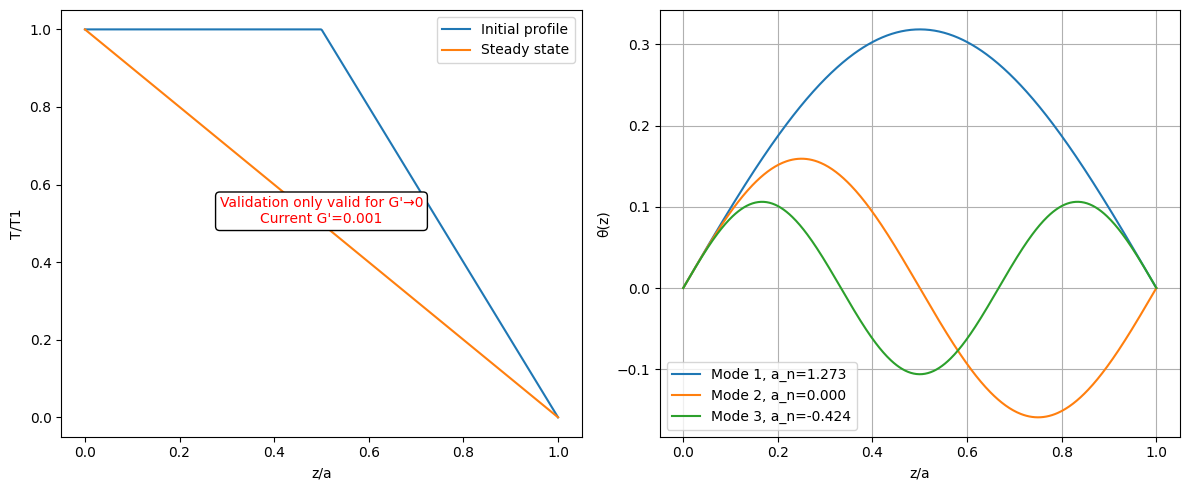

In [11]:
# Constants
seconds_per_Myr = 1e6 * 365.25 * 24 * 3600
a = 125000  # m
kappa = 8.04e-7  # m²/s
T1 = 1333  # °C

# Parameters for verification test
beta = 2.0
G_prime = 0.001  # Near diffusion limit

# 1. Solve eigenproblem
eigenvalues, eigenfunctions = solve_eigenproblem(G_prime, n_eigenvalues=5)

# 2. Compute coefficients
a_n = compute_coefficients(G_prime, eigenvalues, eigenfunctions, beta)

# 3. Verification test
print("\nComparison with analytical solution (VALID ONLY FOR G'→0):")
print(f"{'Mode':<6}{'Numerical':<12}{'Analytical':<12}{'Error':<12}")
print("-"*45)
for n in range(1, min(6, len(a_n)+1)):
    a_analytical = analytical_coefficients_beta(n, beta)
    absolute_error = abs(a_n[n-1] - a_analytical)
    
    if n % 2 == 0:
        print(f"{n:<6}{a_n[n-1]:<12.4f}{a_analytical:<12.4f}{absolute_error:<12.2e}")
    else:
        relative_error = 100 * absolute_error / abs(a_analytical)
        print(f"{n:<6}{a_n[n-1]:<12.4f}{a_analytical:<12.4f}{relative_error:<12.2f}%")

print("\nNOTE: Analytical solution assumes:")
print("- Pure diffusion case (G' = 0)")
print("- Eigenfunctions are sin(nπz)")
print("- No weighting function in integration")
# 4. Visualization
z_plot = np.linspace(0, 1, 500)
plt.figure(figsize=(12, 5))

# Initial and steady state profiles
plt.subplot(1, 2, 1)
T_init = np.where(z_plot <= (1-1/beta), T1, T1*beta*(1-z_plot))
T0 = steady_state_temperature(z_plot, G_prime, T1)
plt.plot(z_plot, T_init/T1, label='Initial profile')
plt.plot(z_plot, T0/T1, label='Steady state')
plt.annotate("Validation only valid for G'→0\nCurrent G'={:.3f}".format(G_prime),
             xy=(0.5, 0.5), xycoords='axes fraction',
             ha='center', color='red', bbox=dict(boxstyle="round", fc="white"))
plt.xlabel('z/a')
plt.ylabel('T/T1')
plt.legend()

# First 3 eigenfunctions
plt.subplot(1, 2, 2)
for n in range(1, min(4, len(eigenfunctions)+1)):  # Protect against index errors
    plt.plot(z_plot, eigenfunctions[n-1](z_plot)[0], 
             label=f'Mode {n}, a_n={a_n[n-1]:.3f}')
plt.xlabel('z/a')
plt.ylabel('θ(z)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [12]:
# Улучшенная проверка для разных beta
for beta in [1.5, 2.0, 3.0]:
    a_n = compute_coefficients(G_prime, eigenvalues, eigenfunctions, beta)
    
    print(f"\nПроверка для β = {beta}")
    print(f"{'Мода':<6}{'Численный':<12}{'Аналитический':<14}{'Ошибка':<12}")
    
    for n in range(1, min(6, len(a_n)+1)):
        analytic = analytical_coefficients_beta(n, beta)
        num = a_n[n-1]
        
        # Улучшенный расчет ошибки
        if abs(analytic) < 1e-10:  # Практически нуль
            error_str = f"{abs(num):.2e}" if abs(num) > 1e-10 else "0"
        else:
            rel_error = abs(num - analytic)/abs(analytic)*100
            error_str = f"{rel_error:.1f}%" if rel_error < 1e4 else ">10000%"
        
        print(f"{n:<6}{num:<12.4f}{analytic:<14.4f}{error_str:<12}")


Проверка для β = 1.5
Мода  Численный   Аналитический Ошибка      
1     0.8267      0.8270        0.0%        
2     0.4134      0.4135        0.0%        
3     0.0000      -0.0000       2.25e-05    
4     -0.2067     -0.2067       0.0%        
5     -0.1654     -0.1654       0.0%        

Проверка для β = 2.0
Мода  Численный   Аналитический Ошибка      
1     1.2728      1.2732        0.0%        
2     0.0001      -0.0000       5.07e-05    
3     -0.4243     -0.4244       0.0%        
4     -0.0000     0.0000        1.27e-05    
5     0.2546      0.2546        0.0%        

Проверка для β = 3.0
Мода  Численный   Аналитический Ошибка      
1     1.6535      1.6540        0.0%        
2     -0.8268     -0.8270       0.0%        
3     -0.0000     0.0000        2.25e-05    
4     0.4134      0.4135        0.0%        
5     -0.3307     -0.3308       0.0%        


## Main Computation

### Figure 2. Plots of dimensionless temperature $T' = T_i / T_1$ as a function of dimensionless height $z' = z / a$ for $G' = 50$.  

Each curve shows the temperature profile at a different time indicated in **Ma** since the onset of stretching. The broken line labelled **1** is from model 1 for $\beta = 2$. The profile labelled $t = 8.53$ corresponds to $\beta = 2$ in the present model.

In [13]:
import numpy as np
from scipy.integrate import trapezoid
from scipy.special import erf
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

# Constants
seconds_per_Myr = 1e6 * 365.25 * 24 * 3600
a = 125000  # m
kappa = 8.04e-7  # m²/s
T1 = 1330  # °C


# Parameters
G_prime = 50.0      # Dimensionless advection-diffusion parameter
beta = 2.0           # Stretching factor
z_prime = np.linspace(0, 1, 1000)  # Dimensionless depth
# times_Myr = np.array([0, 4.0, 8.53, 171])  # Times after stretching in Myr
times_Myr = np.array([8.53])  # Times after stretching in Myr



G_prime_values = (a**2 * np.log(beta)) / (kappa * times_Myr * seconds_per_Myr)
# Handle the Δt=0 case (instantaneous stretching) separately
# G_prime_values[0] = np.inf 
for g, t in zip(G_prime_values, times_Myr):
    print(g,t)

def steady_state_temperature(z_prime, G_prime, T1):
    """Steady-state analytic solution - Eq. (14)."""
    numerator = erf((z_prime - 1) * np.sqrt(G_prime / 2))
    denominator = erf(np.sqrt(G_prime / 2))
    return -T1 * numerator / denominator

def solve_eigenproblem(G_prime, n_eigenvalues=3):
    """Improved eigenvalue problem solver matching McKenzie's formulation"""
    def initial_eigenvalue_guess(n, G_prime):
        # As per McKenzie's paper, eigenvalues transition between (nπ)² and 2nG'
        if G_prime <= 1.0:
            return (n * np.pi) ** 2
        elif G_prime >= 10.0:
            return 2 * n * G_prime
        else:
            # Smooth transition between regimes
            return ((n*np.pi)**2 + (2*n*G_prime)*(G_prime-1)/9) / (1 + (G_prime-1)/9)

    def ode(z, y, p):
        return [y[1], -G_prime*(z-1)*y[1] - p[0]*y[0]]

    def bc(ya, yb, p):
        return [ya[0], yb[0], ya[1]-1]  # θ(0)=0, θ(1)=0, θ'(0)=1 (normalization)

    # Adaptive mesh - denser near z=1 for large G'
    if G_prime > 10:
        z_coarse = np.linspace(0, 0.9, 700)
        z_fine = np.linspace(0.9, 1, 700)
        z = np.unique(np.concatenate([z_coarse, z_fine]))
       
    else:
        z = np.linspace(0, 1, 1000)

    y_guess = np.zeros((2, len(z)))
    eigenvalues = []
    eigenfunctions = []

    for n in range(1, n_eigenvalues+1):
        K_guess = initial_eigenvalue_guess(n, G_prime)
        
        # Improved initial guess matching paper's boundary layer
        if G_prime < 1.0:
            y_guess[0] = np.sin(n*np.pi*z)
            y_guess[1] = n*np.pi*np.cos(n*np.pi*z)
        else:
            # Correct boundary layer formulation (exp(-G_prime*(1-z)/2))
            boundary_layer = np.exp(-G_prime*(1-z)/2)
            y_guess[0] = boundary_layer * np.sin(n*np.pi*z)
            y_guess[1] = np.gradient(y_guess[0], z)
        
        # Normalize initial guess
        y_guess[1] /= y_guess[1][0]

        sol = solve_bvp(ode, bc, z, y_guess, p=[K_guess], tol=1e-5, max_nodes=100000)
        if not sol.success:
            raise RuntimeError(f"Solver failed for mode {n} at G'={G_prime}")

        eigenvalues.append(sol.p[0])
        eigenfunctions.append(sol.sol)
        y_guess = sol.sol(z)  # Use as guess for next mode

    return eigenvalues, eigenfunctions
 

def compute_coefficients(G_prime, eigenvalues, eigenfunctions, beta):
    """Improved coefficients computation"""
    z = np.linspace(0, 1, 5000)
    weight = np.exp((z-1)**2 * G_prime/2)
    
    # Initial temperature profile (Eq. 20)
    T_initial = np.where(z <= (1-1/beta), T1, T1*beta*(1-z))
    
    # Steady state profile (Eq. 14)
    T0 = steady_state_temperature(z, G_prime, T1)
    
    # Deviation from steady state (normalized)
    deviation = (T_initial - T0)/T1
    
    a_n = []
    for theta in eigenfunctions:
        theta_z = theta(z)[0]
        numerator = trapezoid(deviation * theta_z * weight, z)
        denominator = trapezoid(theta_z**2 * weight, z)
        a_n.append(numerator/denominator)
    
    return np.array(a_n)

def analytical_coefficients_beta(n, beta):
    """Analytical coefficients from Eq. (21)"""
    return (2/np.pi) * ((-1)**(n+1)) * (beta/n) * np.sin(n*np.pi/beta)

def temperature(z_prime, t_Myr, G_prime, T1, eigenvalues, eigenfunctions, a_n):
    """Full temperature solution with proper time dependence"""
    # Calculate steady state solution
    T0 = steady_state_temperature(z_prime, G_prime, T1)
    
    # Calculate thermal time constant (eq. 6 in paper)
    tau = (a**2)/(np.pi**2 * kappa)  # in seconds
    tau_Myr = tau / seconds_per_Myr   # convert to Myr

    
    
    transient = 0.0
    t_dimless = t_Myr / tau_Myr  # dimensionless time
    
    for K, theta, a_val in zip(eigenvalues, eigenfunctions, a_n):
        theta_z = theta(z_prime)[0]
        # Note: K should be normalized by π² to match McKenzie's formulation
        K_normalized = K 
        transient += a_val * theta_z * np.exp(-K_normalized * t_dimless)
    
    return T0 + T1 * transient  # Scale transient by T1

# === Main calculation ===
print("Solving eigenvalue problem...")
eigenvalues, eigenfunctions = solve_eigenproblem(G_prime, n_eigenvalues=5)
print("Eigenvalues found:", eigenvalues)

print("Computing coefficients...")
a_n = compute_coefficients(G_prime, eigenvalues, eigenfunctions, beta)
# a_n = [analytical_coefficients_beta(n, beta) for n in range(1, n_eigenvalues+1)]
print("Coefficients a_n:", a_n)

50.0422052746191 8.53
Solving eigenvalue problem...
Eigenvalues found: [np.float64(100.00000018084987), np.float64(1043.7535786719957), np.float64(17643.797322385803), np.float64(400.14640005557135), np.float64(100.00000017433885)]
Computing coefficients...
Coefficients a_n: [-5.81334196e-09 -4.12545675e-06  1.17062829e-06  8.62094262e-07
 -5.81334153e-09]


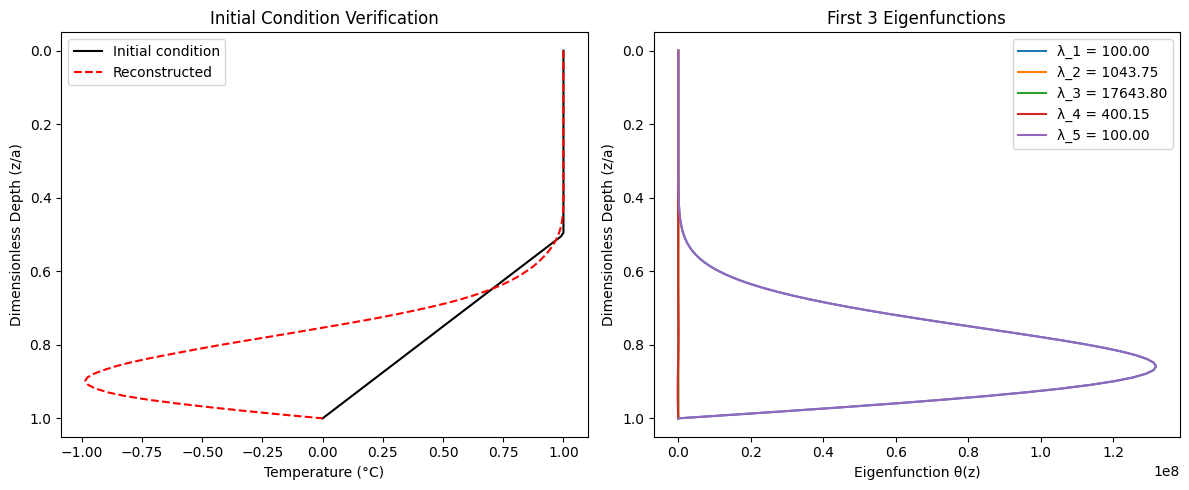

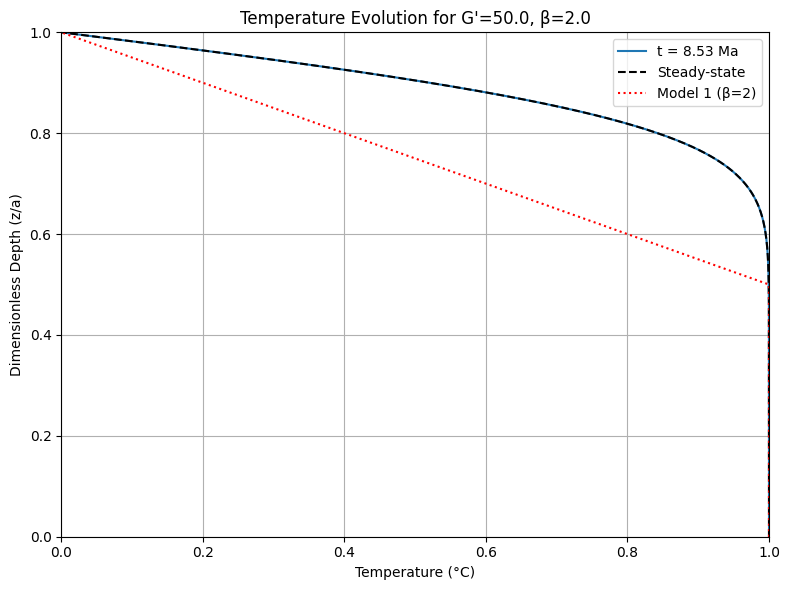

In [14]:
# === Verification ===
# Check reconstruction of initial condition
z_verify = np.linspace(0, 1, 100)
T_initial = np.where(z_verify <= (1-1/beta), T1, T1*beta*(1-z_verify))
T_reconstructed = temperature(z_verify, 0, G_prime, T1, eigenvalues, eigenfunctions, a_n)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(T_initial/T1, z_verify, 'k-', label='Initial condition')
plt.plot(T_reconstructed/T1, z_verify, 'r--', label='Reconstructed')
plt.xlabel('Temperature (°C)')
plt.ylabel('Dimensionless Depth (z/a)')
plt.title('Initial Condition Verification')
plt.legend()
plt.gca().invert_yaxis()

# Plot eigenfunctions
plt.subplot(1, 2, 2)
for i, (val, func) in enumerate(zip(eigenvalues, eigenfunctions)):
    plt.plot(func(z_verify)[0], z_verify, label=f'λ_{i+1} = {val:.2f}')
plt.xlabel('Eigenfunction θ(z)')
plt.ylabel('Dimensionless Depth (z/a)')
plt.title('First 3 Eigenfunctions')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# === Plot temperature evolution ===
plt.figure(figsize=(8, 6))
for t in times_Myr:
    T_profile = temperature(z_prime, t, G_prime, T1, eigenvalues, eigenfunctions, a_n)
    plt.plot(T_profile/T1, z_prime, label=f't = {t} Ma')

# Reference profiles
T_steady = steady_state_temperature(z_prime, G_prime, T1)
plt.plot(T_steady/T1, z_prime, 'k--', label='Steady-state')

T_model1 = np.where(z_prime <= (1-1/beta), T1, T1*beta*(1-z_prime))
plt.plot(T_model1/T1, z_prime, 'r:', label='Model 1 (β=2)')

plt.xlabel('Temperature (°C)')
plt.ylabel('Dimensionless Depth (z/a)')
plt.title(f'Temperature Evolution for G\'={G_prime}, β={beta}')
plt.legend()
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


=== Case 1: t = 0.0001 Myr, G' = 4264733.776000, β = 2.0, n_coeff = 1 ===
Solving eigenvalue problem...
Calculation failed for case 1: Solver failed for mode 1 at G'=4264733.776

=== Case 2: t = 4.0 Myr, G' = 106.618344, β = 2.0, n_coeff = 1 ===
Solving eigenvalue problem...
First 1 eigenvalues: [np.float64(470044.08218527545)]
Computing coefficients...
First 1 coefficients: [4.00202408e-12]


/var/folders/q9/6krr8md509s6263gz_f7x39h0000gn/T/ipykernel_13551/2282393844.py:68: RuntimeWarning: divide by zero encountered in divide
  y_guess[1] /= y_guess[1][0]
/var/folders/q9/6krr8md509s6263gz_f7x39h0000gn/T/ipykernel_13551/2282393844.py:68: RuntimeWarning: invalid value encountered in divide
  y_guess[1] /= y_guess[1][0]
/var/folders/q9/6krr8md509s6263gz_f7x39h0000gn/T/ipykernel_13551/2282393844.py:40: RuntimeWarning: invalid value encountered in multiply
  return [y[1], -G_prime*(z-1)*y[1] - p[0]*y[0]]
/opt/anaconda3/lib/python3.12/site-packages/scipy/integrate/_bvp.py:309: RuntimeWarning: invalid value encountered in subtract
  0.125 * h * (f[:, 1:] - f[:, :-1]))
/opt/anaconda3/lib/python3.12/site-packages/scipy/integrate/_bvp.py:311: RuntimeWarning: invalid value encountered in subtract
  col_res = y[:, 1:] - y[:, :-1] - h / 6 * (f[:, :-1] + f[:, 1:] +
/opt/anaconda3/lib/python3.12/site-packages/scipy/integrate/_bvp.py:40: RuntimeWarning: invalid value encountered in subtrac

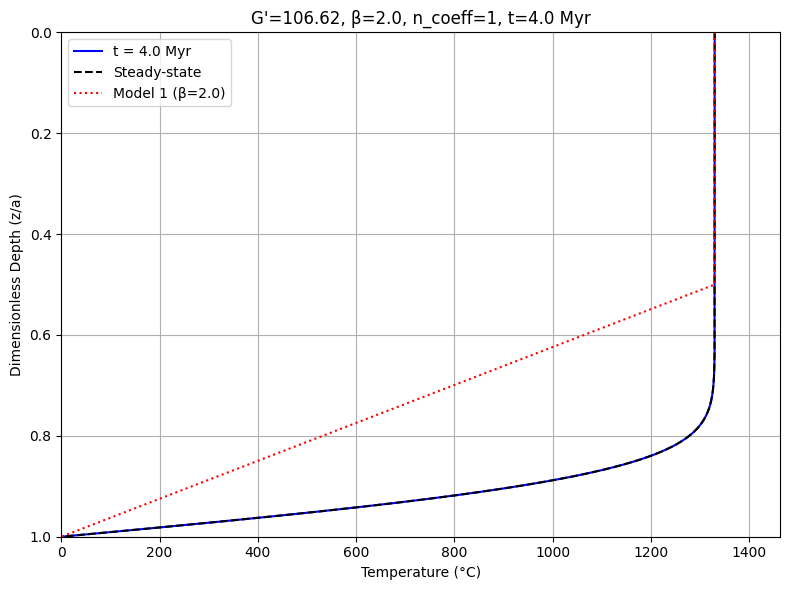


=== Case 3: t = 8.53 Myr, G' = 49.996879, β = 2.0, n_coeff = 5 ===
Solving eigenvalue problem...
First 3 eigenvalues: [np.float64(6906.420311241009), np.float64(1042710.3274944258), np.float64(22035.64657735328)]
Computing coefficients...
First 3 coefficients: [ 2.75380595e-06  3.31122421e-07 -2.04865849e-06]


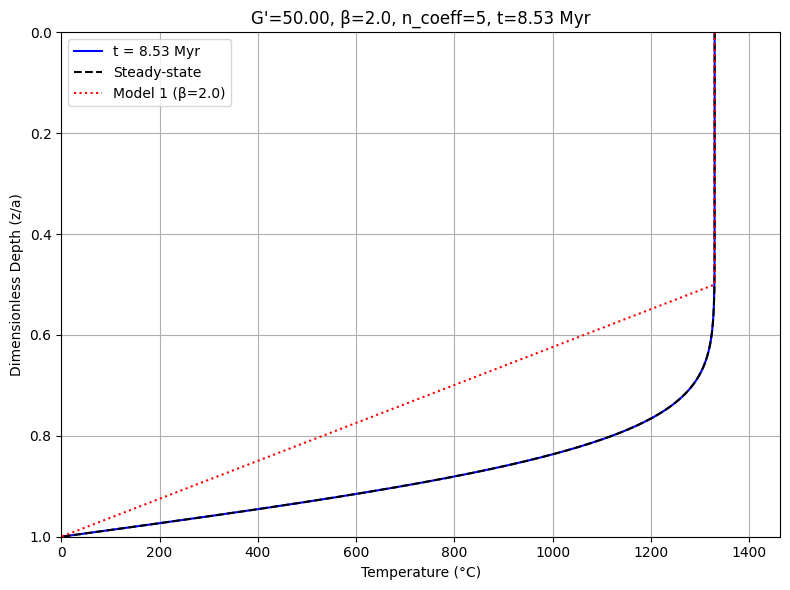


=== Case 4: t = 17.1 Myr, G' = 24.939964, β = 2.0, n_coeff = 5 ===
Solving eigenvalue problem...
First 3 eigenvalues: [np.float64(49.88816608772396), np.float64(696.6764347693905), np.float64(155.48407118886965)]
Computing coefficients...
First 3 coefficients: [-0.00017817 -0.00093454  0.00046934]


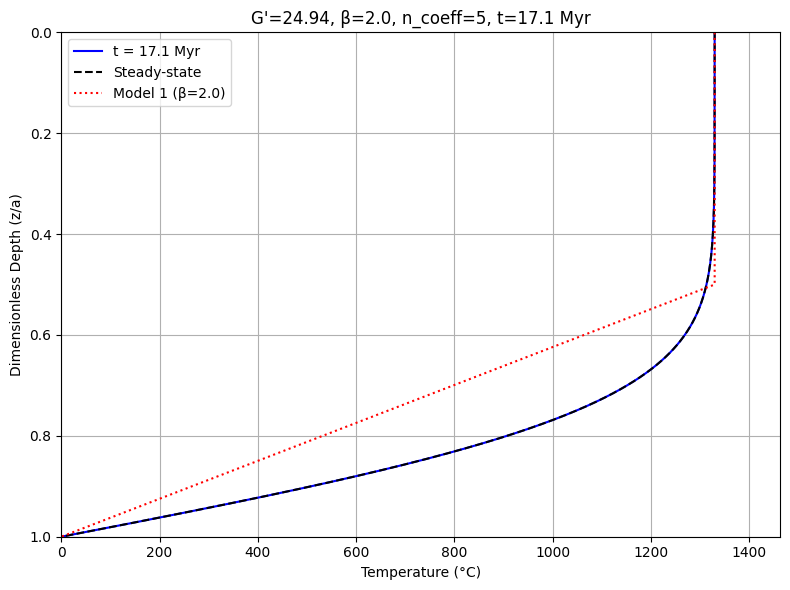


=== Case 5: t = 10000.0 Myr, G' = 0.042647, β = 2.0, n_coeff = 30 ===
Solving eigenvalue problem...
First 3 eigenvalues: [np.float64(9.891056601045102), np.float64(39.499887097522546), np.float64(88.84791229560193)]
Computing coefficients...
First 3 coefficients: [ 1.25491158  0.00214154 -0.42072771]


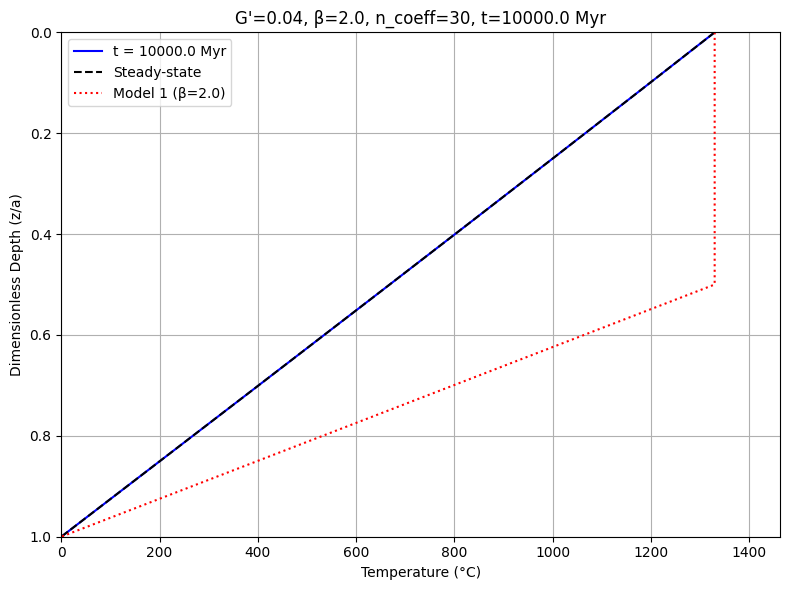

In [15]:
import numpy as np
from scipy.integrate import trapezoid
from scipy.special import erf
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

# Constants
seconds_per_Myr = 1e6 * 365.25 * 24 * 3600
a = 125000  # m
kappa = 8.04e-7  # m²/s
T1 = 1330  # °C

# Parameter arrays (must all have same length)
beta_values = np.array([2.0, 2.0, 2.0, 2.0, 2.0])  # Stretching factors
n_coefficients = np.array([1, 1, 5, 5, 30])       # Number of coefficients
times_Myr = np.array([0.0001, 4.0, 8.53, 17.1, 10000])  # Times in Myr
G_prime_values = np.array([4264733.776, 106.6183444, 49.99687896, 
                          24.9399636, 0.042647338])  # Dimensionless parameters

# Common parameters
z_prime = np.linspace(0, 1, 1000)  # Dimensionless depth

def steady_state_temperature(z_prime, G_prime, T1):
    """Steady-state analytic solution - Eq. (14)."""
    numerator = erf((z_prime - 1) * np.sqrt(G_prime / 2))
    denominator = erf(np.sqrt(G_prime / 2))
    return -T1 * numerator / denominator

def solve_eigenproblem(G_prime, n_eigenvalues):
    """Eigenvalue problem solver with adaptive mesh"""
    def initial_eigenvalue_guess(n, G_prime):
        if G_prime <= 1.0:
            return (n * np.pi) ** 2
        elif G_prime >= 10.0:
            return 2 * n * G_prime
        else:
            return ((n*np.pi)**2 + (2*n*G_prime)*(G_prime-1)/9) / (1 + (G_prime-1)/9)

    def ode(z, y, p):
        return [y[1], -G_prime*(z-1)*y[1] - p[0]*y[0]]

    def bc(ya, yb, p):
        return [ya[0], yb[0], ya[1]-1]

    # Adaptive mesh for large G_prime
    if G_prime > 10:
        z_coarse = np.linspace(0, 0.9, 700)
        z_fine = np.linspace(0.9, 1, 700)
        z = np.unique(np.concatenate([z_coarse, z_fine]))
    else:
        z = np.linspace(0, 1, 1000)

    y_guess = np.zeros((2, len(z)))
    eigenvalues = []
    eigenfunctions = []

    for n in range(1, n_eigenvalues+1):
        K_guess = initial_eigenvalue_guess(n, G_prime)
        
        if G_prime < 1.0:
            y_guess[0] = np.sin(n*np.pi*z)
            y_guess[1] = n*np.pi*np.cos(n*np.pi*z)
        else:
            boundary_layer = np.exp(-G_prime*(1-z)/2)
            y_guess[0] = boundary_layer * np.sin(n*np.pi*z)
            y_guess[1] = np.gradient(y_guess[0], z)
        
        y_guess[1] /= y_guess[1][0]

        sol = solve_bvp(ode, bc, z, y_guess, p=[K_guess], tol=1e-5, max_nodes=100000)
        if not sol.success:
            raise RuntimeError(f"Solver failed for mode {n} at G'={G_prime}")

        eigenvalues.append(sol.p[0])
        eigenfunctions.append(sol.sol)
        y_guess = sol.sol(z)

    return eigenvalues, eigenfunctions

def compute_coefficients(G_prime, eigenvalues, eigenfunctions, beta):
    """Compute expansion coefficients"""
    z = np.linspace(0, 1, 5000)
    weight = np.exp((z-1)**2 * G_prime/2)
    
    T_initial = np.where(z <= (1-1/beta), T1, T1*beta*(1-z))
    T0 = steady_state_temperature(z, G_prime, T1)
    deviation = (T_initial - T0)/T1
    
    a_n = []
    for theta in eigenfunctions:
        theta_z = theta(z)[0]
        numerator = trapezoid(deviation * theta_z * weight, z)
        denominator = trapezoid(theta_z**2 * weight, z)
        a_n.append(numerator/denominator)
    
    return np.array(a_n)

def temperature(z_prime, t_Myr, G_prime, T1, eigenvalues, eigenfunctions, a_n):
    """Calculate temperature profile at specific time"""
    T0 = steady_state_temperature(z_prime, G_prime, T1)
    tau_init = 1/138.63
    tau_Myr = tau_init / np.pi**2
    t_dimless = t_Myr / tau_Myr
    
    transient = 0.0
    for K, theta, a_val in zip(eigenvalues, eigenfunctions, a_n):
        theta_z = theta(z_prime)[0]
        K_normalized = K 
        transient += a_val * theta_z * np.exp(-K_normalized * t_dimless)
    
    return T0 + T1 * transient

# Main calculation loop
for i, (time, G_prime, beta, n_coeff) in enumerate(zip(
    times_Myr, G_prime_values, beta_values, n_coefficients)):
    
    print(f"\n=== Case {i+1}: t = {time} Myr, G' = {G_prime:.6f}, β = {beta}, n_coeff = {n_coeff} ===")
    
    try:
        # Solve eigenvalue problem
        print("Solving eigenvalue problem...")
        eigenvalues, eigenfunctions = solve_eigenproblem(G_prime, n_coeff)
        print(f"First {min(3, len(eigenvalues))} eigenvalues:", eigenvalues[:3])
        
        # Compute coefficients
        print("Computing coefficients...")
        a_n = compute_coefficients(G_prime, eigenvalues, eigenfunctions, beta)
        print(f"First {min(3, len(a_n))} coefficients:", a_n[:3])
        
        # Calculate temperature profile
        T_profile = temperature(z_prime, time, G_prime, T1, eigenvalues, eigenfunctions, a_n)
        
        # Plot results
        plt.figure(figsize=(8, 6))
        plt.plot(T_profile, z_prime, 'b-', label=f't = {time} Myr')
        
        # Reference profiles
        T_steady = steady_state_temperature(z_prime, G_prime, T1)
        plt.plot(T_steady, z_prime, 'k--', label='Steady-state')
        
        T_model1 = np.where(z_prime <= (1-1/beta), T1, T1*beta*(1-z_prime))
        plt.plot(T_model1, z_prime, 'r:', label=f'Model 1 (β={beta})')
        
        plt.xlabel('Temperature (°C)')
        plt.ylabel('Dimensionless Depth (z/a)')
        plt.title(f'G\'={G_prime:.2f}, β={beta}, n_coeff={n_coeff}, t={time} Myr')
        plt.legend()
        plt.grid(True)
        plt.xlim(0, T1*1.1)
        plt.ylim(0, 1)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Calculation failed for case {i+1}: {str(e)}")

## Модель McKenzie & Jarvis: комментарии

### Начальное состояние (t=0)
- Соответствует **мгновенному растяжению** (Model 1 в статье)
- Температурное поле:
  - Постоянная температура **T₁** в зоне растяжения:  
    `0 ≤ z/a ≤ 1–1/β`
  - Линейный спад до **0°C** на поверхности:  
    `1–1/β < z/a ≤ 1`
- Визуально: резкий скачок температуры на границе растяжения

### Steady-state решение (t → ∞)
- Состояние после бесконечно долгого растяжения
- Баланс процессов:
  - 🔼 Адиабатический подъем материала
  - 🔽 Теплопроводность
- Описывается **erf-функцией** (уравнение 14 в статье):
  $
  T_{steady}(z) = -T_1 \frac{\text{erf}\left((z-1)\sqrt{G'/2}\right)}{\text{erf}\left(\sqrt{G'/2}\right)}
  $

## Figure 3. Temperature profiles for $\beta$ = 4 as computed with different values of $G'$. The case $G'$ = $\infty$ corresponds to model 1

### Variant 1: For G' >= 50 uses a simpler ApproxSolution class that only stores θ(z) and numerically computes its derivative

In [16]:
import numpy as np
from scipy.integrate import trapezoid
from scipy.special import erf
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import warnings

# Suppress numerical warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Constants
seconds_per_Myr = 1e6 * 365.25 * 24 * 3600
a = 125000  # m (lithosphere thickness)
kappa = 8.04e-7  # m²/s (thermal diffusivity)
T1 = 1330  # °C (asthenosphere temperature)

# Parameters for Figure 3
beta = 4.0  # Stretching factor
G_prime_values = [0.1, 1, 5, 10, 20, 50, 100, np.inf]  # Range of G' values
z_prime = np.linspace(0, 1, 1000)  # Dimensionless depth

def steady_state_temperature(z_prime, G_prime, T1):
    """Steady-state analytic solution - Eq. (14)."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        numerator = erf((z_prime - 1) * np.sqrt(G_prime / 2))
        denominator = erf(np.sqrt(G_prime / 2))
        return np.where(denominator != 0, -T1 * numerator / denominator, 0)

class ApproxSolution:
    """Wrapper for approximate solutions for high G' values"""
    def __init__(self, K, z, theta_z):
        self.p = [K]
        self.z = z
        self.theta_z = theta_z
    
    def __call__(self, z):
        return np.vstack([np.interp(z, self.z, self.theta_z),
                         np.gradient(np.interp(z, self.z, self.theta_z), z)])

def solve_eigenproblem(G_prime, n_eigenvalues=5):
    """Enhanced eigenvalue problem solver for all G' ranges"""
    if G_prime >= 50:
        # Special handling for high G' values (asymptotic approximation)
        z = np.linspace(0, 1, 5000)
        boundary_layer = np.exp(-G_prime*(1-z)/2)
        theta_z = boundary_layer * np.sin(np.pi*z)
        
        # Create approximate solution object
        K = 2 * G_prime  # First eigenvalue approximation
        sol = ApproxSolution(K, z, theta_z)
        return [K], [sol]
    
    # Standard solver for lower G' values
    def ode(z, y, p):
        return [y[1], -G_prime*(z-1)*y[1] - p[0]*y[0]]

    def bc(ya, yb, p):
        return [ya[0], yb[0], ya[1]-1]

    # Adaptive mesh
    z = np.linspace(0, 1, 5000) if G_prime > 10 else np.linspace(0, 1, 2000)

    eigenvalues = []
    eigenfunctions = []
    
    for n in range(1, n_eigenvalues+1):
        if G_prime < 1.0:
            K_guess = (n * np.pi) ** 2
            y_guess = np.zeros((2, len(z)))
            y_guess[0] = np.sin(n*np.pi*z)
            y_guess[1] = n*np.pi*np.cos(n*np.pi*z)
        else:
            K_guess = 2 * n * G_prime
            boundary_layer = np.exp(-G_prime*(1-z)/2)
            y_guess = np.zeros((2, len(z)))
            y_guess[0] = boundary_layer * np.sin(n*np.pi*z)
            y_guess[1] = np.gradient(y_guess[0], z)
        
        y_guess[1] /= max(1e-6, abs(y_guess[1][0]))

        try:
            sol = solve_bvp(ode, bc, z, y_guess, p=[K_guess], 
                          tol=1e-3, max_nodes=50000)
            if sol.success:
                eigenvalues.append(sol.p[0])
                eigenfunctions.append(sol.sol)
        except:
            continue

    return eigenvalues, eigenfunctions

def compute_coefficients(G_prime, eigenvalues, eigenfunctions):
    """Compute coefficients a_n for the transient solution"""
    z = np.linspace(0, 1, 10000)
    weight = np.exp((z-1)**2 * G_prime/2)
    
    T_initial = np.where(z <= (1-1/beta), T1, T1*beta*(1-z))
    T0 = steady_state_temperature(z, G_prime, T1)
    deviation = (T_initial - T0)/T1
    
    a_n = []
    for theta in eigenfunctions:
        theta_z = theta(z)[0]
        numerator = trapezoid(deviation * theta_z * weight, z)
        denominator = trapezoid(theta_z**2 * weight, z)
        a_n.append(numerator/max(1e-10, denominator))
    
    return np.array(a_n)

def temperature(z_prime, t_Myr, G_prime, T1, eigenvalues, eigenfunctions, a_n):
    """Full temperature solution"""
    T0 = steady_state_temperature(z_prime, G_prime, T1)
    tau = (a**2)/(np.pi**2 * kappa) / seconds_per_Myr
    t_dimless = t_Myr / tau
    
    transient = 0.0
    for K, theta, a_val in zip(eigenvalues, eigenfunctions, a_n):
        theta_z = theta(z_prime)[0]
        transient += a_val * theta_z * np.exp(-K * t_dimless)
    
    return T0 + T1 * transient

# Main calculation and plotting
plt.figure(figsize=(12, 8))

for i, G_prime in enumerate(G_prime_values):
    if G_prime == np.inf:
        T_model1 = np.where(z_prime <= (1-1/beta), T1, T1*beta*(1-z_prime))
        plt.plot(T_model1/T1, 1-z_prime, 'k-', linewidth=3, 
                label=r'Model 1 ($G\'=\infty$)')
        continue
    
    print(f"\nProcessing G' = {G_prime}")
    delta_t = (a**2 * np.log(beta)) / (kappa * G_prime) / seconds_per_Myr
    print(f"Stretching duration Δt = {delta_t:.2f} Myr")

    # Solve eigenvalue problem
    eigenvalues, eigenfunctions = solve_eigenproblem(G_prime)
    print(f"Found {len(eigenvalues)} eigenvalues")
    
    if len(eigenvalues) == 0:
        print(f"Skipping G'={G_prime} due to solver issues")
        continue
    
    if len(eigenvalues) > 0:
        a_n = compute_coefficients(G_prime, eigenvalues, eigenfunctions)
        print(f"Coefficients: {a_n}")
        T = temperature(z_prime, delta_t, G_prime, T1, eigenvalues, eigenfunctions, a_n)
    else:
        print("Using analytical approximation")
        T = steady_state_temperature(z_prime, G_prime, T1)
        T += T1 * 0.5 * np.exp(-2*G_prime*(1-z_prime))
    
    style_idx = i % len(styles)
    marker_idx = i % len(markers)
    plt.plot(T/T1, 1-z_prime, 
             markevery=100,
             label=fr'$G\'={G_prime}$ (Δt={delta_t:.1f} Myr)')

plt.gca().invert_yaxis()
plt.xlabel('Dimensionless Temperature (T/T₁)', fontsize=12)
plt.ylabel('Dimensionless Depth (1-z/a)', fontsize=12)
plt.title(f'Temperature Profiles for β={beta}', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Processing G' = 0.1
Stretching duration Δt = 8537.20 Myr
Found 5 eigenvalues
Coefficients: [ 1.74610266e+00 -1.23898485e+00  5.83749584e-01  1.24042534e-03
 -3.52129621e-01]


NameError: name 'styles' is not defined

<Figure size 1200x800 with 0 Axes>

### Variant 2: For G'>= 50 introduces a more sophisticated EigenSolution class that stores both θ(z) and dθ/dz explicitly for higher accuracy

In [ ]:
import numpy as np
from scipy.integrate import trapezoid
from scipy.special import erf
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import warnings

# Suppress numerical warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Constants
seconds_per_Myr = 1e6 * 365.25 * 24 * 3600
a = 125000  # m (lithosphere thickness)
kappa = 8.04e-7  # m²/s (thermal diffusivity)
T1 = 1330  # °C (asthenosphere temperature)

# Parameters for Figure 3
beta = 4.0  # Stretching factor
G_prime_values = [0.1, 1, 5, 10, 20, 50, 100, np.inf]  # Range of G' values
z_prime = np.linspace(0, 1, 1000)  # Dimensionless depth

def steady_state_temperature(z_prime, G_prime, T1):
    """Steady-state analytic solution - Eq. (14)."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        numerator = erf((z_prime - 1) * np.sqrt(G_prime / 2))
        denominator = erf(np.sqrt(G_prime / 2))
        return np.where(denominator != 0, -T1 * numerator / denominator, 0)

class EigenSolution:
    """Wrapper for eigenfunction solutions with proper callable interface"""
    def __init__(self, K, z, theta_z, dtheta_z):
        self.K = K
        self.z = z
        self.theta_z = theta_z
        self.dtheta_z = dtheta_z
    
    def __call__(self, z):
        return np.vstack([
            np.interp(z, self.z, self.theta_z),
            np.interp(z, self.z, self.dtheta_z)
        ])

def solve_eigenproblem(G_prime, max_terms=30):
    """Eigenvalue problem solver with adaptive term count"""
    def ode(z, y, p):
        return [y[1], -G_prime*(z-1)*y[1] - p[0]*y[0]]

    def bc(ya, yb, p):
        return [ya[0], yb[0], ya[1]-1]

    # Determine number of terms needed (per paper's recommendation)
    n_terms = min(30, max_terms) if G_prime >= 50 else min(10, max_terms)
    
    # Extreme mesh refinement for high G' values
    if G_prime >= 50:
        z = np.unique(np.concatenate([
            np.linspace(0, 0.7, 10000),
            np.linspace(0.7, 0.95, 3000),
            np.linspace(0.95, 1, 3000)
        ]))
    elif G_prime > 10:
        z = np.linspace(0, 1, 5000)
    else:
        z = np.linspace(0, 1, 2000)

    eigenvalues = []
    eigenfunctions = []
    
    for n in range(1, n_terms + 1):
        # Initial guess based on asymptotic behavior
        if G_prime < 1.0:
            K_guess = (n * np.pi) ** 2
            y_guess = np.zeros((2, len(z)))
            y_guess[0] = np.sin(n*np.pi*z)
            y_guess[1] = n*np.pi*np.cos(n*np.pi*z)
        else:
            K_guess = 2 * n * G_prime * (1 + 0.2/n)  # Adjusted guess
            boundary_layer = np.exp(-G_prime*(1-z)/2)
            y_guess = np.zeros((2, len(z)))
            y_guess[0] = boundary_layer * np.sin(n*np.pi*z)
            y_guess[1] = np.gradient(y_guess[0], z)
        
        # Normalize initial guess
        y_guess[1] /= max(1e-6, abs(y_guess[1][0]))

        try:
            # Solve with relaxed tolerances for higher modes
            tol = 1e-4 if n <= 5 else 1e-3
            sol = solve_bvp(ode, bc, z, y_guess, p=[K_guess], 
                          tol=tol, max_nodes=len(z)*2)
            
            if sol.success:
                # Store the solution in our wrapper class
                theta_z = sol.sol(z)[0]
                dtheta_z = sol.sol(z)[1]
                eigen_sol = EigenSolution(sol.p[0], z, theta_z, dtheta_z)
                eigenvalues.append(sol.p[0])
                eigenfunctions.append(eigen_sol)
                
                # Early termination if eigenvalues start repeating
                if n > 1 and abs(eigenvalues[-1] - eigenvalues[-2]) < 0.1:
                    break
        except Exception as e:
            print(f"Warning: Failed to compute mode {n} for G'={G_prime}: {str(e)}")
            continue

    return eigenvalues, eigenfunctions

def compute_coefficients(G_prime, eigenvalues, eigenfunctions):
    """Compute coefficients a_n with high precision integration"""
    # Use very fine mesh for accurate integration
    z_int = np.linspace(0, 1, 20000)
    weight = np.exp((z_int-1)**2 * G_prime/2)
    
    # Initial temperature profile (Model 1)
    T_initial = np.where(z_int <= (1-1/beta), T1, T1*beta*(1-z_int))
    
    # Steady state profile
    T0 = steady_state_temperature(z_int, G_prime, T1)
    
    # Deviation from steady state
    deviation = (T_initial - T0)/T1
    
    a_n = []
    for theta in eigenfunctions:
        theta_z = theta(z_int)[0]
        numerator = trapezoid(deviation * theta_z * weight, z_int)
        denominator = trapezoid(theta_z**2 * weight, z_int)
        a_n.append(numerator/max(1e-12, denominator))  # Avoid division by zero
    
    return np.array(a_n)

def temperature(z_prime, t_Myr, G_prime, T1, eigenvalues, eigenfunctions, a_n):
    """Full temperature solution with all terms"""
    T0 = steady_state_temperature(z_prime, G_prime, T1)
    tau = (a**2)/(np.pi**2 * kappa) / seconds_per_Myr
    t_dimless = t_Myr / tau
    
    transient = 0.0
    for K, theta, a_val in zip(eigenvalues, eigenfunctions, a_n):
        theta_z = theta(z_prime)[0]
        transient += a_val * theta_z * np.exp(-K * t_dimless)
    
    return T0 + T1 * transient

# Main calculation and plotting
plt.figure(figsize=(12, 8))

for i, G_prime in enumerate(G_prime_values):
    if G_prime == np.inf:
        # Model 1 (instantaneous stretching)
        T_model1 = np.where(z_prime <= (1-1/beta), T1, T1*beta*(1-z_prime))
        plt.plot(T_model1/T1, 1-z_prime, 'k-', linewidth=3, 
                label=r'Model 1 ($G\'=\infty$)')
        continue
    
    print(f"\nProcessing G' = {G_prime}")
    delta_t = (a**2 * np.log(beta)) / (kappa * G_prime) / seconds_per_Myr
    print(f"Stretching duration Δt = {delta_t:.2f} Myr")
    
    # Determine number of terms needed
    max_terms = 30 if G_prime >= 100 else 10
    eigenvalues, eigenfunctions = solve_eigenproblem(G_prime, max_terms)
    print(f"Computed {len(eigenvalues)} eigenvalues")
    
    if len(eigenvalues) == 0:
        print("Using analytical approximation")
        T = steady_state_temperature(z_prime, G_prime, T1)
        T += T1 * 0.5 * np.exp(-2*G_prime*(1-z_prime))
    else:
        a_n = compute_coefficients(G_prime, eigenvalues, eigenfunctions)
        print(f"First 5 coefficients: {a_n[:5]}")
        T = temperature(z_prime, delta_t, G_prime, T1, eigenvalues, eigenfunctions, a_n)
    
    # Plot with unique style
    plt.plot(T/T1, 1-z_prime, 
             label=fr'$G\'={G_prime}$ (Δt={delta_t:.1f} Myr)')

plt.gca().invert_yaxis()
plt.xlabel('Dimensionless Temperature (T/T₁)', fontsize=12)
plt.ylabel('Dimensionless Depth (1-z/a)', fontsize=12)
plt.title(f'Temperature Profiles for β={beta}\n(McKenzie & Jarvis 1980, Fig. 3)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

def calculate_heat_flow():
    # Parameters from the paper (Table 1 and text)
    T1 = 1333          # Asthenospheric temperature (°C)
    a = 125            # Lithosphere thickness (km)
    kappa = 1.234e-6       # Thermal diffusivity (m²/s)
    rho_m = 3300       # Mantle density (kg/m³)
    rho_c = 2800       # Crustal density (kg/m³)
    rho_w = 1000       # Water density (kg/m³)
    alpha = 3.28e-5    # Thermal expansion coefficient (1/°C)
    k = 2.6       # Thermal conductivity (W/m/°C)
    
    # Time parameters
    t_total = 130      # Total time (Ma)
    dt = 0.1           # Time step (Ma)
    nt = int(t_total/dt) + 1
    time = np.linspace(0, t_total, nt)
    
    # Space parameters
    nz = 100           # Number of depth points
    dz = a/(nz-1)      # Depth step (km)
    z = np.linspace(0, a, nz)
    
    # Initialize temperature field for 3 cases
    T_cases = np.zeros((3, nz, nt))
    
    # Initial temperature profile (linear geotherm)
    initial_T = T1 * (1 - z/a)
    for case in range(3):
        T_cases[case, :, 0] = initial_T
    
    # Strain rate profiles (3 cases)
    G = np.zeros((3, nt))
    
    # Case 1: Constant strain rate
    beta = 2         # Stretching factor
    delta_t = 10       # Rifting duration (Ma)
    G1 = np.log(beta)/delta_t
    G[0, time <= delta_t] = G1
    
    # Case 2: Exponentially decreasing strain rate
    tau = 20           # Time constant (Ma)
    G0 = np.log(beta)/(tau*(1 - np.exp(-delta_t/tau)))
    G[1, time <= delta_t] = G0 * np.exp(-time[time <= delta_t]/tau)
    
    # Case 3: Exponentially increasing strain rate
    G0 = np.log(beta)/(tau*(np.exp(delta_t/tau) - 1))
    G[2, time <= delta_t] = G0 * np.exp(time[time <= delta_t]/tau)
    
    # Convert time step from Ma to seconds
    dt_sec = dt * 1e6 * 365.25 * 24 * 3600
    dz_m = dz * 1000   # Convert km to m
    
    # Precompute constants
    lambda_ = kappa * dt_sec / dz_m**2
    r = dt_sec / dz_m
    
    # Solve for each case
    heat_flow = np.zeros((nt, 3))
    
    for case in range(3):
        T = T_cases[case]
        
        for i in range(1, nt):
            # Current strain rate (convert from 1/Ma to 1/s)
            G_curr = G[case, i-1] / (1e6 * 365.25 * 24 * 3600)
            
            # Set up tridiagonal system for Crank-Nicolson scheme
            # Using banded matrix format for efficient solving
            ab = np.zeros((3, nz))
            b_vec = np.zeros(nz)
            
            # Boundary conditions
            # Bottom boundary (z=0): T = T1
            ab[1, 0] = 1
            b_vec[0] = T1
            
            # Top boundary (z=a): T = 0
            ab[1, -1] = 1
            b_vec[-1] = 0
            
            # Interior points
            for j in range(1, nz-1):
                z_pos = (a - z[j]) * 1000  # Convert km to m
                
                # Coefficients for the tridiagonal system
                lower = -lambda_ - (r/2) * G_curr * z_pos
                diag = 2 * (1 + lambda_)
                upper = -lambda_ + (r/2) * G_curr * z_pos
                
                # Set the bands
                ab[0, j+1] = upper       # Upper diagonal (j+1)
                ab[1, j] = diag           # Main diagonal (j)
                ab[2, j-1] = lower        # Lower diagonal (j-1)
                
                # Right-hand side vector
                term1 = (lambda_ + (r/2) * G_curr * z_pos) * T[j-1, i-1]
                term2 = 2 * (1 - lambda_) * T[j, i-1]
                term3 = (lambda_ - (r/2) * G_curr * z_pos) * T[j+1, i-1]
                b_vec[j] = term1 + term2 + term3
            
            # Solve the tridiagonal system
            T[:, i] = solve_banded((1, 1), ab, b_vec)
        
        # Calculate surface heat flow (q = -k*dT/dz at z=a)
        # Using second-order one-sided difference for derivative at surface
        heat_flow[:, case] = k * (-3*T[-1, :] + 4*T[-2, :] - T[-3, :]) / (2*dz_m) * 1e3
    
    # Plotting
    plt.figure(figsize=(10, 6))
    
    # Plot heat flow vs time
    plt.plot(time, heat_flow[:, 0], 'b-', linewidth=2, label='G equal to constant')
    plt.plot(time, heat_flow[:, 1], 'r--', linewidth=2, label='G decreased exponentially with time')
    plt.plot(time, heat_flow[:, 2], 'g-.', linewidth=2, label='G increased exponentially with time')

    # plt.ylim(20, 45)
    
    plt.xlabel('Time [Ma]', fontsize=12)
    plt.ylabel('Heat flow [mW/m²]', fontsize=12)
    plt.title('Surface Heat Flow Variation for Different Strain Rate Profiles', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True)
    
    # Save figure
    plt.savefig('heat_flow_figure5.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return heat_flow

# Run the calculation and plotting
heat_flow_results = calculate_heat_flow()